### Asset Report Analysis

This notebook presents an exploratory analysis of U.S. military gaming machine asset reports compiled from multiple standardized CSV formats.

The main objectives are to:
- Clean and harmonize machine-level asset data across reporting formats.
- Analyze category trends (SLOT, FRS, ACM/ITC) over time and by base/region.
- Examine provider-level market concentration and diversity.
- Generate clear, well-documented exploratory findings to support further statistical and policy analysis.

#### Import Necessary Modules and Packages

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import calendar
from datetime import datetime, date
from pathlib import Path
from IPython.display import display, HTML
import re
import json

VERBOSE = False  # set to True when debugging

def vprint(*args, **kwargs):
    if VERBOSE:
        print(*args, **kwargs)

#### Set Global Plotting Settings and Paramters

In [ ]:
# Matplotlib + Seaborn style
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

# Centralized figure sizes
FIGSIZE_LANDSCAPE = (10, 5)
FIGSIZE_LANDSCAPE_WIDE = (12, 6)
FIGSIZE_SQUARE = (6, 6)

# Centralized font sizes
TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 12
TICK_FONTSIZE = 10

#### Import Necessary CSV Data Files

Import all standardized .csv files. These files were derived from the original PDF asset reports supplied by the client. The PDFs were processed using Adobe Express and MuckRock’s provided OCR tools to extract tabular data. Following extraction, the datasets were cleaned and normalized using a combination of manual review, Excel formulas, and scripted preprocessing to ensure consistent formatting across all asset report versions.

The directory structure for the Asset Report Analysis is shown below:
- data
    - Asset Reports
        - Assset Reports Format 1
            - Asset Report FY20 Format 1.xlsx
            - Asset Report FY21 Format 1.xlsx
            - Asset Report FY22 Format 1.xlsx
            - Asset Report FY23 Format 1.xlsx
            - Asset Report FY24 Format 1.xlsx
    - Assset Report FY20-FY24 Format 1.csv
    - Assset Report FY20-FY24 Format 2.csv
    - Assset Report FY20-FY24 Format 4.csv

#### Paths and Directory

We define input/output locations for all Asset Reports.


In [213]:
# Path Directory for Uploaded Asset Reports
DATA_DIR = Path("data")
ASSET_REPORT_DIR = DATA_DIR / "Asset Reports"

FMT1_XLSX_DIR = ASSET_REPORT_DIR / "Asset Reports Format 1"
FMT1_CSV_PATH = ASSET_REPORT_DIR / "Asset Report FY20-FY24 Format 1.csv"
FMT2_CSV_PATH = ASSET_REPORT_DIR / "Asset Report FY20-FY24 Format 2.csv"
FMT4_CSV_PATH = ASSET_REPORT_DIR / "Asset Report FY20-FY24 Format 4.csv"

BASES_JSON_PATH = DATA_DIR / "bases.json"

##### Read-In Our CSV Data

In this section we load the raw Excel asset report and define helper
functions for parsing header text (titles and reporting dates).


In [214]:
asset_report_fmt1_2020 = pd.read_excel(FMT1_XLSX_DIR / "Asset Report FY20 Format 1.xlsx")
asset_report_fmt1_2021 = pd.read_excel(FMT1_XLSX_DIR / "Asset Report FY21 Format 1.xlsx")
asset_report_fmt1_2022 = pd.read_excel(FMT1_XLSX_DIR / "Asset Report FY22 Format 1.xlsx")
asset_report_fmt1_2023 = pd.read_excel(FMT1_XLSX_DIR / "Asset Report FY23 Format 1.xlsx")
asset_report_fmt1_2024 = pd.read_excel(FMT1_XLSX_DIR / "Asset Report FY24 Format 1.xlsx")
asset_report_fmt1 = pd.read_csv(FMT1_CSV_PATH, low_memory=False)


ar2 = pd.read_csv(FMT2_CSV_PATH, low_memory=False)
ar4 = pd.read_csv(FMT4_CSV_PATH, low_memory=False)

In [ ]:
# Global constants for regions and machine types
REGIONS = ["Europe", "Japan", "Korea"]
MACHINE_COLS = ["Slots", "ACM", "ITC", "FRS"]

REGION_COLORS = {
    "Europe": "#1f77b4",
    "Japan":  "#ff7f0e",
    "Korea":  "#2ca02c",
}

MACHINE_COLORS = {
    "Slots": "#1f77b4",
    "ACM":   "#ff7f0e",
    "ITC":   "#2ca02c",
    "FRS":   "#d62728",
}

### Data Preparation and Preliminary Inspection

The original PDF asset reports were separated into five distinct table formats using Adobe Express and the OCR tools provided by MuckRock. Each extracted table was then exported as a standardized .csv file. Because the formats differ in layout, variable definitions, and structural organization, all subsequent steps—inspection, cleaning, and analysis—are carried out individually for each format.

To assess the suitability of the extracted data for analysis, each format undergoes a preliminary inspection. This review includes verification of row and column structure, examination of variable names and inferred data types, inspection of sample records to confirm accurate extraction, generation of descriptive statistics for quantitative fields, and identification of missing values or other irregularities. Conducting this assessment separately for each format establishes an initial understanding of the dataset and facilitates concurrent analytical work across formats.

Following inspection, each dataset proceeds through a cleaning and standardization stage tailored to its structural characteristics. This process involves correcting OCR-related inconsistencies, standardizing variable names and data types, addressing missing or incomplete values, resolving formatting issues, and validating the plausibility of key variables. These procedures ensure that each format is transformed into a coherent and analytically usable dataset.

Once cleaned, the datasets are prepared for format-specific analytical workflows. Depending on the structure of each format, this may include generating derived variables, restructuring tables through aggregation or pivoting, validating internal consistency, and creating summary outputs. When formats share comparable variables, results may also be synthesized to support broader comparative analysis.

### Format 1

#### 1. Helper Functions (Data Cleaning and Processing)

The helper functions below implement the core parsing and standardization logic for the Format 1 asset reports. They are used throughout the rest of the notebook, but are all defined here in one place for clarity and reproducibility.

- functions `load_raw` and `row_to_text` handle loading OCR-extracted sheets from Excel and normalizing each row into a single, cleaned text string (stripping whitespace and placeholder values like `"nan"`).

- function `find_all_field_office_titles` scans the raw sheet to locate every row that contains a `"EGMs by Field Office"` or `"Assets by Field Office"` table title.

- function `parse_reporting_date_below` walks downward from each title row and extracts the reporting date from nearby header text, handling both exact dates (e.g.`"as of 27 March 2020"`) and month-end summaries (e.g. `"for month of March 2020"` or `"as of EOM March 2021"`).

- function `parse_field_office_block` parses each “Field Office” block row by row: it detects region headers (Europe, Japan, Korea), extracts `Field_Office_ID` and `Field_Office_Name`, and then cleans the numeric section into `Slots`, `ACM`, `ITC`, `FRS`, and `Total`.  During this step it also strips note text such as `"s/b 150"` and treats bare dashes `"-"` as 0, which appear in a few OCR’d rows.

- function `parse_single_fmt1_file` wraps the above helpers for one Excel workbook: it loads the raw sheet, finds all title rows, pairs each block with its reporting date, and returns a list of structured field-office records for that file (while printing the detected title rows, date rows, and number of parsed records).

- functions `build_canonical_names` and `enforce_canonical_names` standardize `Field_Office_Name` across spelling and OCR variants using a reference list in `bases.json`, so that each `(Region, Field_Office_ID)` pair has a single canonical name.

- function `add_coordinates` attaches longitude (`lon`) and latitude (`lat`) from the `bases.json` JSON file to each field office by matching on a normalized name key and applying a small set of manual fixes for known spelling / romanization mismatches (e.g. `"KAISERSLAUTERN"` → `"KAISERLAUTERN"`, `"DAEGU"` → `"TAEGU"`), preparing the dataset for geographic visualization and mapping.

In [215]:
def load_raw(path: Path) -> pd.DataFrame:
    """
    Load the first sheet of an asset report as raw text.

    All cells are read as strings to avoid early type coercion.
    Whitespace is stripped so downstream parsing is consistent.
    """
    raw = pd.read_excel(path, sheet_name=0, header=None, dtype=str)
    raw = raw.apply(lambda col: col.astype(str).str.strip())
    return raw

def row_to_text(row: pd.Series) -> str:
    """
    Collapse a row into a single space-separated string.

    Empty cells and placeholder values ('', 'nan', 'NaN', 'None') are ignored.
    This is useful for parsing merged or fragmented header rows.
    """
    vals = [x for x in row.tolist() if x not in ("", "nan", "NaN", "None")]
    return " ".join(vals).strip()

def find_all_field_office_titles(raw: pd.DataFrame) -> list[int]:
    """
    Locate all rows that contain a Field Office table title.

    Titles may appear as either:
        - 'EGMs by Field Office'
        - 'Assets by Field Office'
    """
    title_rows: list[int] = []

    for i in range(len(raw)):
        txt = row_to_text(raw.iloc[i]).lower()
        if "egms by field office" in txt or "assets by field office" in txt:
            title_rows.append(i)

    return title_rows

def parse_reporting_date_below(
    raw: pd.DataFrame,
    start_row: int,
) -> tuple[date, int]:
    """
    Scan downward from start_row to find a reporting date.

    Supported patterns (case-insensitive, merged cells OK):

      Exact-date snapshots (return that calendar date):
        - 'as of 27 March 2020'
        - 'as of March 27, 2020'

      Month-end snapshots (return last day of that month):
        - 'for month of <Month> <Year>'
        - 'as of <Month> <Year>'
        - 'as of EOM <Month> <Year>'
    """
    month_full = [m.lower() for m in calendar.month_name]
    month_abbr = [m.lower() for m in calendar.month_abbr]

    def _month_to_int(mname: str) -> int:
        m = mname.lower()
        if m in month_full:
            return month_full.index(m)
        if m in month_abbr:
            return month_abbr.index(m)
        raise ValueError(f"Unknown month name: {mname}")

    for i in range(start_row + 1, len(raw)):
        txt = row_to_text(raw.iloc[i])
        low = txt.lower()
        if not low:
            continue

        # Case 1: 'as of 27 March 2020'
        m1 = re.search(r"as of\s+(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})", low)
        if m1:
            day = int(m1.group(1))
            month = _month_to_int(m1.group(2))
            year = int(m1.group(3))
            return date(year, month, day), i

        # Case 2: 'as of March 27, 2020'
        m2 = re.search(r"as of\s+([a-zA-Z]+)\s+(\d{1,2}),?\s+(\d{4})", low)
        if m2:
            month = _month_to_int(m2.group(1))
            day = int(m2.group(2))
            year = int(m2.group(3))
            return date(year, month, day), i

        # Case 3: 'for month of March 2020' -> end of month
        m3 = re.search(r"for month of\s+([a-zA-Z]+)\s+(\d{4})", low)
        if m3:
            month = _month_to_int(m3.group(1))
            year = int(m3.group(2))
            last_day = calendar.monthrange(year, month)[1]
            return date(year, month, last_day), i

        # Case 4: 'as of (eom) March 2021'
        m4 = re.search(
            r"as of(?:\s+eom)?\s+([a-zA-Z]+)(?:\s+\d{1,2},?)?\s+(\d{4})",
            low,
        )
        if m4:
            month = _month_to_int(m4.group(1))
            year = int(m4.group(2))
            last_day = calendar.monthrange(year, month)[1]
            return date(year, month, last_day), i

    raise ValueError(f"No reporting date found below title row {start_row}")

def parse_field_office_block(
    raw: pd.DataFrame,
    start_row: int,
    next_title_row: int | None,
    reporting_date: date,
) -> list[dict]:
    """
    Parse a single 'EGMs/Assets by Field Office' block into row records.

    Each block includes:
      - Region headers (e.g. 'Europe', 'Japan', 'Korea')
      - Field-office rows with:
            Field_Office_ID
            Field_Office_Name
            Slots, ACM, ITC, FRS, Total

    The block ends at the next title row or when summary text is encountered.
    """
    records: list[dict] = []
    current_region: str | None = None

    first_data_row = start_row + 1
    stop_row = next_title_row if next_title_row is not None else len(raw)

    for i in range(first_data_row, stop_row):
        txt = row_to_text(raw.iloc[i])
        low = txt.lower()

        # Skip empty rows
        if not txt:
            continue

        # Block terminators (summary lines)
        if "armp total" in low or "installed assets" in low:
            break

        # Region header (e.g. 'Europe', 'Japan', 'Korea')
        m_region = re.match(r"^(Europe|Japan|Korea)\b", txt, flags=re.IGNORECASE)
        if m_region:
            current_region = m_region.group(1).title()
            continue

        # Ignore data before the first region
        if current_region is None:
            continue

        # Skip totals / percentage rows inside a block
        if "total" in low or "%" in low:
            continue

        tokens = txt.split()
        if not tokens:
            continue

        # 1) Field Office ID = first token (must be integer)
        if not tokens[0].isdigit():
            continue
        field_id = int(tokens[0])

        # 2) Field Office Name = tokens until the first numeric
        name_tokens: list[str] = []
        j = 1
        while j < len(tokens) and not re.fullmatch(r"-?\d+", tokens[j]):
            name_tokens.append(tokens[j])
            j += 1

        if not name_tokens or j >= len(tokens):
            continue

        field_name = " ".join(name_tokens).strip()

        # 3) Numeric section = Slots, ACM, ITC, FRS, Total
        numeric_chunk = " ".join(tokens[j:])

        # Remove notes like "s/b 150" etc.
        numeric_chunk = re.sub(r"(?i)s\s*/\s*b\s*\d*", " ", numeric_chunk)
        numeric_chunk = re.sub(r"\s+", " ", numeric_chunk).strip()

        values: list[int] = []
        for tok in numeric_chunk.split():
            if re.fullmatch(r"-?\d+", tok):
                values.append(int(tok))
            elif tok == "-":
                # treat bare dash as 0
                values.append(0)

        if len(values) < 5:
            continue

        slots, acm, itc, frs, total = values[-5:]

        records.append(
            dict(
                Reporting_Date=reporting_date,
                Region=current_region,
                Field_Office_ID=field_id,
                Field_Office_Name=field_name,
                Slots=slots,
                ACM=acm,
                ITC=itc,
                FRS=frs,
                Total=total,
            )
        )

    return records

def parse_single_fmt1_file(path: Path) -> list[dict]:
    """
    Parse a single Format 1 asset report into structured field-office records.
    """
    raw = load_raw(path)
    title_rows = find_all_field_office_titles(raw)

    if not title_rows:
        print(f"  No field-office blocks found in {path.name}, skipped.")
        return []

    file_records: list[dict] = []
    date_rows_found: list[int] = []

    for i, start_row in enumerate(title_rows):
        next_title_row = title_rows[i + 1] if i + 1 < len(title_rows) else None

        try:
            reporting_date, date_row_idx = parse_reporting_date_below(raw, start_row)
            date_rows_found.append(date_row_idx)
        except ValueError:
            # No reporting date under this title -> skip this block
            continue

        block_records = parse_field_office_block(
            raw=raw,
            start_row=start_row,
            next_title_row=next_title_row,
            reporting_date=reporting_date,
        )
        file_records.extend(block_records)

    print(f"  Title rows: {title_rows}")
    print(f"  Reporting date rows: {date_rows_found}")
    print(f"  Parsed rows: {len(file_records)}")

    return file_records

def build_canonical_names(
    df: pd.DataFrame,
    bases_path: Path = BASES_JSON_PATH,
) -> dict[tuple[str, int], str]:
    """
    For each (Region, Field_Office_ID), choose a canonical Field_Office_Name.

    Priority:
      1. If any name variant matches a base name in bases.json (case-insensitive),
         choose the most frequent such name.
      2. Otherwise, fall back to the most frequent name in the data.
    """
    bases_df = pd.read_json(bases_path)
    valid_names = (
        bases_df["name"].astype(str).str.upper().str.strip().unique()
    )
    valid_names_set = set(valid_names)

    canon: dict[tuple[str, int], str] = {}
    grouped = df.groupby(["Region", "Field_Office_ID"])

    for (region, office_id), group in grouped:
        names = group["Field_Office_Name"].astype(str)
        names_norm = names.str.upper().str.strip()

        counts = names_norm.value_counts()
        valid_mask = counts.index.isin(valid_names_set)
        valid_candidates = counts[valid_mask]

        if not valid_candidates.empty:
            chosen_norm = valid_candidates.idxmax()
        else:
            chosen_norm = counts.idxmax()

        original_example = names[names_norm == chosen_norm].iloc[0]
        canon[(region, office_id)] = original_example

    return canon

def enforce_canonical_names(
    df: pd.DataFrame,
    canon_map: dict[tuple[str, int], str],
) -> pd.DataFrame:
    """
    Replace all Field_Office_Name values using canonical names to eliminate
    inconsistent naming variations.
    """
    df = df.copy()

    for (region, office_id), canon_name in canon_map.items():
        mask = (df["Region"] == region) & (df["Field_Office_ID"] == office_id)
        df.loc[mask, "Field_Office_Name"] = canon_name

    return df

def add_coordinates(
    df: pd.DataFrame,
    bases_path: Path = BASES_JSON_PATH,
) -> pd.DataFrame:
    """
    Add 'lon' (longitude) and 'lat' (latitude) columns using bases.json.

    Matching is done on a normalized office-name key:
    - If Field_Office_Name_raw exists, use that for matching.
    - Otherwise, use Field_Office_Name.
    - Known spelling / romanization mismatches are fixed via fix_map.
    """
    df = df.copy()

    # Drop any old coord/helper columns
    drop_cols = [
        "lat_x",
        "lat_y",
        "lon_x",
        "lon_y",
        "lat",
        "lon",
        "Field_Office_Name_clean",
        "Region_clean",
        "fo_norm",
        "name_norm",
    ]
    for col in drop_cols:
        if col in df.columns:
            df = df.drop(columns=[col])

    bases_df = pd.read_json(bases_path)
    bases_df["name_norm"] = bases_df["name"].astype(str).str.upper().str.strip()
    bases_df = bases_df.drop_duplicates(subset="name_norm", keep="first")

    name_col = (
        "Field_Office_Name_raw"
        if "Field_Office_Name_raw" in df.columns
        else "Field_Office_Name"
    )

    df["fo_norm"] = df[name_col].astype(str).str.upper().str.strip()

    fix_map = {
        "KAISERSLAUTERN": "KAISERLAUTERN",
        "SOUDA BAY": "SOUDHA BAY",
        "SIGONELLA": "SIGONELLA SICILY",
        "SINGAPORE": "SINGAPORESINGAPORE",
        "DAEGU": "TAEGU",
        "UIJEONGBU": "UIJONG BU",
        "PYONGTAEK": "PYONG TAEK",
    }
    df["fo_norm"] = df["fo_norm"].replace(fix_map)

    df = df.merge(
        bases_df[["name_norm", "lat", "lon"]],
        left_on="fo_norm",
        right_on="name_norm",
        how="left",
    )

    missing = df["lat"].isna().sum()
    vprint(f"[add_coordinates] Rows without coordinate matches: {missing}")

    df = df.drop(columns=["fo_norm", "name_norm"])

    # Reorder columns so lon, lat come before 'Slots' if present
    if {"lon", "lat", "Slots"}.issubset(df.columns):
        cols = list(df.columns)
        cols.remove("lon")
        cols.remove("lat")
        insert_pos = cols.index("Slots")
        cols = cols[:insert_pos] + ["lon", "lat"] + cols[insert_pos:]
        df = df[cols]

    return df

#### 2. Preliminary Inspection of Format 1 Excel Data

##### 2.1 Original OCR Output (2020 & 2021)

Before parsing, we examine the raw OCR-extracted Format 1 tables as they appear when initially loaded from Excel. These previews illustrate several structural issues common in OCR-generated spreadsheets:
- merged text in the first column (multiple regions combined)
- placeholder columns (`Unnamed:x`)
- misaligned headers
- blank rows and missing values
- totals and percentages mixed with data rows

Comparing 2020 and 2021 helps confirm that these problems occur across years, not just in a single file.

In [216]:
print("Format 1 — Year 2020 (original)")
display(asset_report_fmt1_2020.head())

print("\nFormat 1 — Year 2021 (original)")
display(asset_report_fmt1_2021.head())

Format 1 — Year 2020 (original)


,Slots Only # Locations,Unnamed: 1,Unnamed: 2,Army,Unnamed: 4,Navy,Marine Corps,Airforce,Unnamed: 8,Unnamed: 9,Total,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,Europe 34\nJapan 33\nKor...,NaN,NaN,615,NaN,168,-,-,NaN,NaN,783,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.5%\n37.2%\n23.3%,NaN
2,NaN,NaN,NaN,57,NaN,291,390,-,NaN,NaN,738,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,437,NaN,25,-,-,NaN,NaN,462,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Format 1 — Year 2021 (original)


,Slots Only # Locations,Unnamed: 1,Unnamed: 2,Unnamed: 3,Army,Unnamed: 5,Navy,Unnamed: 7,Unnamed: 8,Marine Corps,...,Airforce,Unnamed: 13,Unnamed: 14,Total,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,Europe 34\nJapan 34\nKor...,NaN,NaN,NaN,605,NaN,168,NaN,NaN,-,...,-,NaN,NaN,773,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.4%\n37.3%\n23.3%
2,NaN,NaN,NaN,NaN,69,NaN,291,NaN,NaN,373,...,-,NaN,NaN,733,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,432,NaN,25,NaN,NaN,-,...,-,NaN,NaN,457,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2.2 Converted Raw Text Output

Next, we load the same files using the `load_raw()` helper function, which converts every cell to text and strips whitespace. This produces a simplified representation of the OCR output, removing Excel-specific formatting while preserving the structural inconsistencies that must be handled during parsing.

This view highlights issues such as:
- multi-line text broken into a single cell,
- header rows split across multiple columns,
- placeholder `nan` values filling most cells,
- inconsistent positioning of service-branch columns.

In [217]:
asset_report_fmt1_2020 = load_raw(FMT1_XLSX_DIR / "Asset Report FY20 Format 1.xlsx")
asset_report_fmt1_2021 = load_raw(FMT1_XLSX_DIR / "Asset Report FY21 Format 1.xlsx")

print("Format 1 — Year 2020 (converted to raw text)")
display(asset_report_fmt1_2020.head())

print("\nFormat 1 — Year 2021 (converted to raw text)")
display(asset_report_fmt1_2021.head())

Format 1 — Year 2020 (converted to raw text)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,Slots Only # Locations,nan,nan,Army,nan,Navy,Marine Corps,Airforce,nan,nan,Total,nan,nan,nan,nan
1,Europe 34\nJapan 33\nKor...,nan,nan,615,nan,168,-,-,nan,nan,783,nan,nan,nan,nan
2,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,39.5%\n37.2%\n23.3%,nan
3,nan,nan,nan,57,nan,291,390,-,nan,nan,738,nan,nan,nan,nan
4,nan,nan,nan,437,nan,25,-,-,nan,nan,462,nan,nan,nan,nan



Format 1 — Year 2021 (converted to raw text)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,Slots Only # Locations,nan,nan,nan,Army,nan,Navy,nan,nan,Marine Corps,...,Airforce,nan,nan,Total,nan,nan,nan,nan,nan,nan
1,Europe 34\nJapan 34\nKor...,nan,nan,nan,605,nan,168,nan,nan,-,...,-,nan,nan,773,nan,nan,nan,nan,nan,nan
2,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,39.4%\n37.3%\n23.3%
3,nan,nan,nan,nan,69,nan,291,nan,nan,373,...,-,nan,nan,733,nan,nan,nan,nan,nan,nan
4,nan,nan,nan,nan,432,nan,25,nan,nan,-,...,-,nan,nan,457,nan,nan,nan,nan,nan,nan


### 3. Assembling the Unified Dataset

To assemble a unified dataset, all Excel files that follow the `Asset Report FY* Format 1.xlsx` naming convention are identified and processed. Each file is parsed using the `parse_single_fmt1_file()` function, which extracts all field-office blocks, reporting dates, and numeric records into a structured list. During parsing, the script prints two useful row-level indicators from the original Excel workbook:

- the row index where each field-office title was detected
- the row index where each reporting date was extracted

These references make it easy for the user to trace any parsed output back to its exact location in the source file and verify correctness.

In [218]:
files_fmt1 = sorted(FMT1_XLSX_DIR.glob("Asset Report FY* Format 1.xlsx"))

fmt1_records: list[dict] = []
for path in files_fmt1:
    print(f"\nProcessing: {path.name}")
    fmt1_records.extend(parse_single_fmt1_file(path))


Processing: Asset Report FY20 Format 1.xlsx
  Title rows: [8, 51, 94, 140, 183, 227, 270, 313, 356, 399]
  Reporting date rows: [9, 52, 95, 141, 184, 228, 271, 314, 357, 400]
  Parsed rows: 210

Processing: Asset Report FY21 Format 1.xlsx
  Title rows: [8, 54, 99, 144, 185, 228, 272, 316, 360, 404, 448, 492, 536, 580, 624, 668]
  Reporting date rows: [9, 55, 100, 145, 186, 229, 273, 317, 361, 405, 449, 493, 537, 581, 625, 669]
  Parsed rows: 336

Processing: Asset Report FY22 Format 1.xlsx
  Title rows: [8, 52, 96, 140, 184, 228, 272, 316, 360, 404, 448, 492, 536]
  Reporting date rows: [9, 53, 97, 141, 185, 229, 273, 317, 361, 405, 449, 493, 537]
  Parsed rows: 273

Processing: Asset Report FY23 Format 1.xlsx
  Title rows: [8, 51, 94, 137, 180, 223, 266, 309, 352, 395, 438, 481]
  Reporting date rows: [9, 52, 95, 138, 181, 224, 267, 310, 353, 396, 439, 482]
  Parsed rows: 252

Processing: Asset Report FY24 Format 1.xlsx
  Title rows: [11, 57, 105, 152, 198, 246, 292, 340, 388]
  Repo

After parsing all Format 1 files and collecting the extracted row records, we assemble them into a single DataFrame. The Reporting_Date column is converted to a proper datetime type, and we display the first few rows to verify the structure of the merged dataset.

In [219]:
fmt1_df = pd.DataFrame(fmt1_records)
fmt1_df["Reporting_Date"] = pd.to_datetime(fmt1_df["Reporting_Date"])

print("\nDisplay preview of assembled Format 1 dataframe:")
display(fmt1_df.head())


Display preview of assembled Format 1 dataframe:


,Reporting_Date,Region,Field_Office_ID,Field_Office_Name,Slots,ACM,ITC,FRS,Total
0,2020-01-31,Europe,2,KAISERSLAUTERN,170,11,13,7,201
1,2020-01-31,Europe,4,VICENZA,73,5,5,3,86
2,2020-01-31,Europe,10,GARMISCH,23,2,2,1,28
3,2020-01-31,Europe,31,ANSBACH,36,2,4,2,44
4,2020-01-31,Europe,39,SOUDA BAY,24,2,2,1,29


### 3. Standardizing Field Office Names

The raw extracted data contains multiple naming variations for the same field office across different reports. To ensure consistent identifiers, we first generate a canonical name mapping with `build_canonical_names()`, then apply it back to the dataset with `enforce_canonical_names()` This step removes name-level noise and ensures that each field office appears under one standardized label.
For example, the Japan field office ZAMA was incorrectly captured as ZANA in some rows; the canonicalization process resolves these inconsistencies automatically.

In [220]:
canon_map = build_canonical_names(fmt1_df)
fmt1_df = enforce_canonical_names(fmt1_df, canon_map)

### 4. Removing Exact Duplicate Records

After assembling the combined dataset, we perform one final cleaning step to remove exact duplicate rows. A row is treated as a true duplicate only if all identifying and numeric fields match, including:

- `Reporting_Date`
- `Region`
- `Field_Office_ID`
- `Field_Office_Name`
- `Slots, ACM, ITC, FRS, Total`

This step is necessary because some single Excel files for Asset Report Format 1 contain repeated copies of the same reporting block (for example, the same March 2020 field-office table appearing twice within the same workbook). These internal repeats come from the structure of the original asset reports. If left unfiltered, they would inflate counts, distort summary statistics, and introduce duplicated rows into the Datasette database.

Using this definition, the dataset is de-duplicated on the (`Reporting_Date`, `Region`, `Field_Office_ID`) keys, ensuring that only true repeated copies of identical records are removed, while preserving valid observations from different reporting dates. The printed summary shows how many exact duplicates were dropped and the final row count, and users can review all detected duplicate groups directly in the notebook.


In [221]:
# Inspect duplicate keys
key_cols = ["Reporting_Date", "Region", "Field_Office_ID"]

dupe_counts = (
    fmt1_df.groupby(key_cols)
        .size()
        .reset_index(name="Count")
        .sort_values("Count", ascending=False)
)

# Filter groups with more than 1 row
multi = dupe_counts[dupe_counts["Count"] > 1]

print("\nKeys with potential duplicate rows:")
display(multi)

# Show a sample duplicate block
if not multi.empty:
    sample_key = tuple(multi.iloc[0][key_cols])

    print(f"\nExample duplicate records for key: {sample_key}")
    display(
        fmt1_df[
            (fmt1_df["Reporting_Date"] == sample_key[0]) &
            (fmt1_df["Region"] == sample_key[1]) &
            (fmt1_df["Field_Office_ID"] == sample_key[2])
        ]
    )
else:
    print("\nNo duplicate keys detected.")

# Drop exact row-level duplicates
full_cols = [
    "Reporting_Date",
    "Region",
    "Field_Office_ID",
    "Field_Office_Name",
    "Slots",
    "ACM",
    "ITC",
    "FRS",
    "Total",
]

before = len(fmt1_df)
fmt1_df  = fmt1_df.drop_duplicates(subset=full_cols, keep="first")
after = len(fmt1_df )

print("\nDuplicate Removal Summary:")
print(f" - Exact duplicates dropped: {before - after}")
print(f" - Final row count: {after}")


Keys with potential duplicate rows:


,Reporting_Date,Region,Field_Office_ID,Count
410,2021-07-31,Japan,17,2
411,2021-07-31,Japan,18,2
556,2022-03-31,Europe,47,2
412,2021-07-31,Japan,19,2
413,2021-07-31,Japan,22,2
...,...,...,...,...
562,2022-03-31,Japan,27,2
563,2022-03-31,Korea,20,2
564,2022-03-31,Korea,21,2
565,2022-03-31,Korea,23,2



Example duplicate records for key: (Timestamp('2021-07-31 00:00:00'), 'Japan', np.int64(17))


,Reporting_Date,Region,Field_Office_ID,Field_Office_Name,Slots,ACM,ITC,FRS,Total
452,2021-07-31,Japan,17,SINGAPORE,15,1,2,1,19
473,2021-07-31,Japan,17,SINGAPORE,15,1,2,1,19



Duplicate Removal Summary:
 - Exact duplicates dropped: 147
 - Final row count: 1113


### 5. Adding Geographic Coordinates

This function matches each standardized Field_Office_Name against entries in bases.json and appends two new fields: 

- `lon` — longitude

- `lat`— latitude

These coordinates allow downstream spatial analysis and geographic visualizations (e.g., Datasette maps, or point-based plots).

In [222]:
fmt1_df = add_coordinates(fmt1_df)

print("\nDisplay Preview of Dataframe:")
fmt1_df.head()


Display Preview of Dataframe:


,Reporting_Date,Region,Field_Office_ID,Field_Office_Name,lon,lat,Slots,ACM,ITC,FRS,Total
0,2020-01-31,Europe,2,KAISERSLAUTERN,7.749126,49.440066,170,11,13,7,201
1,2020-01-31,Europe,4,VICENZA,11.535421,45.545479,73,5,5,3,86
2,2020-01-31,Europe,10,GARMISCH,11.095498,47.491695,23,2,2,1,28
3,2020-01-31,Europe,31,ANSBACH,10.571936,49.300425,36,2,4,2,44
4,2020-01-31,Europe,39,SOUDA BAY,24.153585,35.537632,24,2,2,1,29


### 6. Export Final Dataframe as CSV (Format 1)


After all parsing, cleaning, de-duplication, and coordinate merging steps are complete, the final structured dataset is exported to a CSV file named `Asset Report FY20-FY24 Format1`. This file will serve as the input for all downstream analysis and visualization work for `Asset Report Format`.

The CSV is saved in the project’s data/ directory under the `fa25-team-a\data\Asset Reports`. This ensures the processed Format 1 dataset is fully reproducible and can be loaded directly in the next notebook section without re-running the extraction pipeline.

In [223]:
fmt1_df.to_csv(FMT1_CSV_PATH, index=False)

### 7. Exploratory Data Analysis of Format 1 Asset Reports

#### 7.1 Helper Functionos (EDA)

The helper functions below implement the exploratory data analysis data preparation for the Format 1 asset reports. They are used throughout the rest of the notebook, but are all defined here in one place for clarity and reproducibility.

- `finalize_plot`

In [224]:
def prep_format1_for_eda(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare the Format 1 dataset for exploratory analysis.
    - Converts Reporting_Date to datetime and drops invalid rows.
    - Adds Year and Month columns.
    - Ensures all machine columns are numeric.
    - Computes Total machines as Slots + ACM + ITC + FRS.
    """
    df = df.copy()

    df["Reporting_Date"] = pd.to_datetime(df["Reporting_Date"], errors="coerce")
    df = df.dropna(subset=["Reporting_Date"])

    df["Year"] = df["Reporting_Date"].dt.year
    df["Month"] = df["Reporting_Date"].dt.month

    machine_cols = ["Slots", "ACM", "ITC", "FRS"]
    df[machine_cols] = df[machine_cols].apply(pd.to_numeric, errors="coerce")

    df["Total"] = df[machine_cols].sum(axis=1)

    return df

def snapshot_by_period(
    df: pd.DataFrame,
    period_code: str,
    machine_cols: list[str] | None = None,
) -> pd.DataFrame:
    """
    Build an end-of-period snapshot summary.

    period_code: 'Y' (year), 'Q' (quarter), 'M' (month).

    For each period:
      1. Find the last Reporting_Date inside the period.
      2. Filter rows to that last date.
      3. Sum machine counts across all field offices on that date.
    """
    df = df.copy()
    df["Reporting_Date"] = pd.to_datetime(df["Reporting_Date"], errors="coerce")
    df = df.dropna(subset=["Reporting_Date"])

    if period_code == "Y":
        group_col = "Year"
        df[group_col] = df["Reporting_Date"].dt.year
    elif period_code == "Q":
        group_col = "Quarter"
        df[group_col] = df["Reporting_Date"].dt.to_period("Q")
    elif period_code == "M":
        group_col = "Month"
        df[group_col] = df["Reporting_Date"].dt.to_period("M")
    else:
        raise ValueError("period_code must be one of: 'Y', 'Q', 'M'")

    if machine_cols is None:
        machine_cols = ["Slots", "ACM", "ITC", "FRS"]

    df[machine_cols] = df[machine_cols].apply(pd.to_numeric, errors="coerce")
    if "Total" not in df.columns:
        df["Total"] = df[machine_cols].sum(axis=1)

    last_dates = (
        df.groupby(group_col)["Reporting_Date"]
        .max()
        .rename("Last_Report_Date")
        .reset_index()
    )

    df_snap = df.merge(last_dates, on=group_col)
    df_snap = df_snap[df_snap["Reporting_Date"] == df_snap["Last_Report_Date"]]

    summary = (
        df_snap.groupby(group_col)[machine_cols + ["Total"]].sum().sort_index()
    )

    return summary

def summarize_data(
    df: pd.DataFrame,
    region: str | None = None,
    freq: str = "Annually",
    machine_cols: list[str] | None = None,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Build a snapshot summary for a given region (or all regions) and frequency.

    freq ∈ {"Annually", "Quarterly", "Monthly"}.
    """
    period_map = {"Annually": "Y", "Quarterly": "Q", "Monthly": "M"}
    if freq not in period_map:
        raise ValueError("freq must be one of: 'Annually', 'Quarterly', 'Monthly'")

    sub = df.copy()
    if region is not None:
        sub = sub[sub["Region"] == region].copy()

    summary = snapshot_by_period(sub, period_map[freq], machine_cols)

    if verbose:
        region_label = region if region is not None else "All regions"
        print(f"\n=== {freq} snapshot — {region_label} ===")
        display(summary.head())

    return summary

def display_multi_data_summaries(
    month_df: pd.DataFrame,
    quarter_df: pd.DataFrame,
    year_df: pd.DataFrame,
    region: str | None = None,
) -> None:
    """
    Display Month / Quarter / Year snapshot tables in a single horizontal row.
    """
    title = f"<h3>Snapshot Summary — {region}</h3>" if region else ""

    html = f"{title}<div style='display:flex; gap:25px; align-items:flex-start;'>"

    for df_, label in [
        (month_df, "Monthly Snapshot"),
        (quarter_df, "Quarterly Snapshot"),
        (year_df, "Yearly Snapshot"),
    ]:
        html += f"""
        <div style="flex:1;">
            <h4 style="margin-bottom:5px;">{label}</h4>
            {df_.to_html()}
        </div>
        """

    html += "</div>"
    display(HTML(html))

#### 7.2 Perform Basic Preparation of Format 1 Dataset for EDA

Before running any exploratory analysis, we re-initialize the key date and numeric fields from the cleaned CSV export. Although the cleaning pipeline already normalized these values, exporting to CSV stores all our fields as strings, so we must convert them back into the correct types for time-series operations and aggregations.

Specifically:
- convert `Reporting_Date` back to a proper datetime object
- derive the analysis-friendly `Year` variable
- ensure all machine-count columns (`Slots`, `ACM`, `ITC`, `FRS`) are numeric
- recompute `Total` for safety and consistency

This small preparation step guarantees that quarterly summaries, growth trends, and region-level comparisons work correctly throughout the EDA section. Using the finalized CSV dataset produced from the data-cleaning and processing pipeline, the next step is to explore how machine installations are distributed across field offices over time and across regions. This section examines temporal trends, regional differences, and base-level machine composition using standardized visualizations built on the cleaned Format 1 dataset.

In [225]:
# Use in-memory cleaned dataset if available; otherwise load from CSV.
try:
    eda_df = fmt1_df.copy()
    print("Using in-memory cleaned dataset: fmt1_df")
except NameError:
    print("fmt1_df not found — loading from exported CSV")
    eda_df = pd.read_csv(FMT1_CSV_PATH)

eda_df = prep_format1_for_eda(eda_df)

print("\nEDA-ready DataFrame shape:", eda_df.shape)
print("\nDisplay preview of EDA DataFrame:")
display(eda_df.head())

Using in-memory cleaned dataset: fmt1_df

EDA-ready DataFrame shape: (1113, 13)

Display preview of EDA DataFrame:


,Reporting_Date,Region,Field_Office_ID,Field_Office_Name,lon,lat,Slots,ACM,ITC,FRS,Total,Year,Month
0,2020-01-31,Europe,2,KAISERSLAUTERN,7.749126,49.440066,170,11,13,7,201,2020,1
1,2020-01-31,Europe,4,VICENZA,11.535421,45.545479,73,5,5,3,86,2020,1
2,2020-01-31,Europe,10,GARMISCH,11.095498,47.491695,23,2,2,1,28,2020,1
3,2020-01-31,Europe,31,ANSBACH,10.571936,49.300425,36,2,4,2,44,2020,1
4,2020-01-31,Europe,39,SOUDA BAY,24.153585,35.537632,24,2,2,1,29,2020,1


#### 7.3 Exploratory Data Analysis of Format 1 Dataset by Region and Frequency

In [226]:
# Europe
eu_month = summarize_data(eda_df, "Europe", freq="Monthly", verbose=False)
eu_quarter = summarize_data(eda_df, "Europe", freq="Quarterly", verbose=False)
eu_year = summarize_data(eda_df, "Europe", freq="Annually", verbose=False)

display_multi_data_summaries(
    eu_month.head(12),
    eu_quarter.head(12),
    eu_year,
    region="Europe"
)

,Slots,ACM,ITC,FRS,Total
Month,,,,,
2020-01,783,49,56,33,921
2020-02,783,49,56,33,921
2020-03,783,49,56,33,921
2020-04,783,49,56,33,921
2020-05,783,49,56,33,921
2020-06,783,49,56,33,921
2020-07,783,49,56,33,921
2020-08,783,49,56,33,921
2020-09,776,49,56,33,914


In [227]:
# Japan
jp_month = summarize_data(eda_df, "Japan", freq="Monthly", verbose=False)
jp_quarter = summarize_data(eda_df, "Japan", freq="Quarterly", verbose=False)
jp_year = summarize_data(eda_df, "Japan", freq="Annually", verbose=False)

display_multi_data_summaries(
    jp_month .head(12),
    jp_quarter .head(12),
    jp_year,
    region="Japan",
)

,Slots,ACM,ITC,FRS,Total
Month,,,,,
2020-01,753,38,56,32,879
2020-02,755,38,56,32,881
2020-03,756,38,57,32,883
2020-04,756,38,57,32,883
2020-05,756,38,57,32,883
2020-06,754,38,57,32,881
2020-07,754,38,57,32,881
2020-08,663,38,57,32,790
2020-09,717,38,57,32,844


In [228]:
# Korea
kr_month = summarize_data(eda_df, "Korea", freq="Monthly", verbose=False)
kr_quarter = summarize_data(eda_df, "Korea", freq="Quarterly", verbose=False)
kr_year = summarize_data(eda_df, "Korea", freq="Annually", verbose=False)

display_multi_data_summaries(
    kr_month.head(12),
    kr_quarter.head(12),
    kr_year,
    region="Korea"
)

,Slots,ACM,ITC,FRS,Total
Month,,,,,
2020-01,447,23,30,17,517
2020-02,445,23,30,17,515
2020-03,427,19,26,15,487
2020-04,427,19,26,15,487
2020-05,435,20,27,15,497
2020-06,438,20,27,15,500
2020-07,438,20,27,15,500
2020-08,430,20,25,14,489
2020-09,421,19,25,14,479


#### 8. Plot and Visualize of Format 1 Dataset

#### 8.1 Helper Functions (Plotting)

The helper functions below implement the exploratory data analysis data preparation for the Format 1 asset reports. They are used throughout the rest of the notebook, but are all defined here in one place for clarity and reproducibility.

- `finalize_plot`

In [ ]:
# Variables

regions = ["Europe", "Japan", "Korea"]          # if not already defined
machine_cols = ["Slots", "ACM", "ITC", "FRS"]   # REQUIRED
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # palette

In [ ]:
def last_snapshot_per_year(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a dataframe containing only the last Reporting_Date snapshot
    for each year.
    """
    tmp = df.copy()
    tmp["Reporting_Date"] = pd.to_datetime(tmp["Reporting_Date"], errors="coerce")
    tmp = tmp.dropna(subset=["Reporting_Date"])
    tmp["Year"] = tmp["Reporting_Date"].dt.year

    last_dates = (
        tmp.groupby("Year")["Reporting_Date"]
        .max()
        .rename("Last_Report_Date")
        .reset_index()
    )

    tmp = tmp.merge(last_dates, on="Year")
    return tmp[tmp["Reporting_Date"] == tmp["Last_Report_Date"]]

def yearly_region_snapshot(df: pd.DataFrame, machine_col: str) -> pd.DataFrame:
    """
    For a given machine type (e.g. 'Slots'), build a Year×Region snapshot
    using the last reporting date within each year.
    """
    snap = last_snapshot_per_year(df)

    out = (
        snap.groupby(["Year", "Region"])[machine_col]
        .sum()
        .reset_index()
    )
    return out

def plot_all_machine_types_grid(df: pd.DataFrame) -> None:
    """
    2×2 grid of grouped bar charts (Slots, ACM, ITC, FRS).
    Y-axis is capped at 80 for ACM, ITC, FRS for readability.
    """
    machine_types = ["Slots", "ACM", "ITC", "FRS"]
    regions = VALID_REGIONS
    region_colors = REGION_COLORS

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    for ax, machine_col in zip(axes, machine_types):
        snap = yearly_region_snapshot(df, machine_col)
        years = sorted(snap["Year"].unique())
        x = np.arange(len(years))
        width = 0.22

        for i, reg in enumerate(regions):
            vals = [
                snap.loc[
                    (snap["Year"] == yr) & (snap["Region"] == reg),
                    machine_col,
                ].iloc[0]
                if not snap[(snap["Year"] == yr) & (snap["Region"] == reg)].empty
                else 0
                for yr in years
            ]

            offset = (i - 1) * width
            bars = ax.bar(
                x + offset,
                vals,
                width,
                color=region_colors[reg],
                label=reg,
            )

            for bar, v in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (3 if machine_col == "Slots" else 1),
                    f"{int(v):,}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

        ax.set_xticks(x)
        ax.set_xticklabels(years)
        ax.set_title(
            f"Total {machine_col} Machines by Region & Year",
            fontsize=12,
        )
        ax.set_xlabel("Year", fontsize=10)
        ax.set_ylabel("Number of Electronic Gaming Machines", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        if machine_col in ["ACM", "ITC", "FRS"]:
            ax.set_ylim(0, 80)

    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            label=reg,
            markerfacecolor=col,
            markersize=10,
        )
        for reg, col in region_colors.items()
    ]

    fig.legend(
        handles=handles,
        title="Region",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
    )

    plt.tight_layout()
    plt.show()

def dashboard_region(df: pd.DataFrame, region: str) -> None:
    """
    Regional dashboard with three panels:
    1) Trend of total machines over time (left, wide)
    2) Top 10 field offices by average total machines (middle)
    3) Machine-type composition pie chart (right)
    """
    snap = summarize_data(df, region=region, freq="Annually", verbose=False)
    if snap.empty:
        print(f"No data for region: {region}")
        return

    years = snap.index.astype(str)
    latest_year = snap.index.max()
    composition = snap.loc[latest_year, ["Slots", "ACM", "ITC", "FRS"]]

    snap_full = last_snapshot_per_year(df)
    snap_reg = snap_full[snap_full["Region"] == region]

    top10 = (
        snap_reg.groupby("Field_Office_Name")["Total"]
        .mean()
        .rename("Avg_Total")
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )

    machine_colors = {
        "Slots": "#1f77b4",
        "ACM": "#ff7f0e",
        "ITC": "#2ca02c",
        "FRS": "#d62728",
    }

    labels = composition.index.tolist()
    values = composition.values.astype(float)
    total = values.sum()
    percents = values / total * 100
    colors = [machine_colors[l] for l in labels]
    legend_labels = [f"{lbl} ({int(v):,})" for lbl, v in zip(labels, values)]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(24, 6),
        gridspec_kw={"width_ratios": [1.5, 1.2, 1.3]},
    )

    ax_trend, ax_top10, ax_pie = axes
    fig.subplots_adjust(wspace=0.35)

    # Trend
    ax_trend.plot(years, snap["Total"], marker="o", linewidth=2, color="steelblue")
    ax_trend.set_title(
        f"{region} — Total Machines Over Time",
        fontsize=14,
        fontweight="bold",
    )
    ax_trend.set_xlabel("Year", fontsize=11)
    ax_trend.set_ylabel("Total Machines", fontsize=11)
    ax_trend.grid(alpha=0.3)
    ax_trend.tick_params(axis="x", rotation=45, labelsize=9)

    # Top 10 bases
    y_pos = np.arange(len(top10))
    ax_top10.barh(y_pos, top10["Avg_Total"], color="steelblue")
    ax_top10.set_yticks(y_pos)
    ax_top10.set_yticklabels(top10["Field_Office_Name"], fontsize=9)
    ax_top10.invert_yaxis()
    ax_top10.set_title(
        f"{region} – Top 10 Field Offices",
        fontsize=14,
        fontweight="bold",
    )
    ax_top10.set_xlabel("Average Total Machines", fontsize=10)

    for i, v in enumerate(top10["Avg_Total"]):
        ax_top10.text(v + 1, i, f"{v:.1f}", va="center", fontsize=8)

    # Pie
    ax_pie.set_position([0.68, 0.12, 0.30, 0.76])

    wedges, _ = ax_pie.pie(
        values,
        colors=colors,
        startangle=90,
        counterclock=False,
    )

    ax_pie.set_title(
        f"{region} — Machine Composition ({latest_year})",
        fontsize=14,
        fontweight="bold",
    )

    label_r = 1.12
    for wedge, pct in zip(wedges, percents):
        theta = 0.5 * (wedge.theta1 + wedge.theta2)
        theta_rad = np.deg2rad(theta)
        ax_pie.text(
            label_r * np.cos(theta_rad),
            label_r * np.sin(theta_rad),
            f"{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

    ax_pie.legend(
        wedges,
        legend_labels,
        title="Machine type",
        loc="center left",
        bbox_to_anchor=(1.15, 0.5),
        fontsize=9,
        title_fontsize=10,
        frameon=False,
    )

    ax_pie.set_aspect("equal")

    plt.tight_layout()
    plt.show()

def plot_top_bottom_bases(df: pd.DataFrame, n: int = 10) -> None:
    """
    Plot top N and bottom N field offices by average Total machines,
    with region-based colors and right-side legend.
    """
    color_map = REGION_COLORS

    avg_totals = (
        df.groupby(["Field_Office_Name", "Region"])["Total"]
        .mean()
        .reset_index()
        .sort_values("Total")
    )

    bottom = avg_totals.head(n)
    top = avg_totals.tail(n)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)

    # Bottom N
    ax = axes[0]
    bottom_sorted = bottom.sort_values("Total")

    colors = bottom_sorted["Region"].map(color_map)
    bars = ax.barh(bottom_sorted["Field_Office_Name"], bottom_sorted["Total"], color=colors)

    for bar, val in zip(bars, bottom_sorted["Total"]):
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f"{val:.0f}", va="center", fontsize=9)

    ax.set_title(f"Bottom {n} Field Offices (Avg Total)", fontsize=14)
    ax.set_xlabel("Average Machines", fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.invert_yaxis()

    # Top N
    ax = axes[1]
    top_sorted = top.sort_values("Total")

    colors = top_sorted["Region"].map(color_map)
    bars = ax.barh(top_sorted["Field_Office_Name"], top_sorted["Total"], color=colors)

    for bar, val in zip(bars, top_sorted["Total"]):
        ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f"{val:.0f}", va="center", fontsize=9)

    ax.set_title(f"Top {n} Field Offices (Avg Total)", fontsize=14)
    ax.set_xlabel("Average Machines", fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.invert_yaxis()

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color_map[reg], label=reg)
        for reg in VALID_REGIONS
    ]

    fig.legend(
        handles=legend_handles,
        title="Region",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=11,
        title_fontsize=12,
    )

    plt.tight_layout()
    plt.show()

def get_snapshot(df: pd.DataFrame, year: int, month: int) -> pd.Series | None:
    sub = df[df["Reporting_Date"].dt.year == year]
    sub = sub[sub["Reporting_Date"].dt.month == month]
    if sub.empty:
        return None
    last_date = sub["Reporting_Date"].max()
    return sub[sub["Reporting_Date"] == last_date].groupby("Region")["Total"].sum()

def get_region_snapshot(
    df: pd.DataFrame,
    year: int,
    month: int,
) -> pd.DataFrame:
    sub = df[df["Reporting_Date"].dt.year == year]
    sub = sub[sub["Reporting_Date"].dt.month == month]
    last_date = sub["Reporting_Date"].max()
    snap = sub[sub["Reporting_Date"] == last_date]

    return (
        snap.groupby("Region")[machine_cols]
        .sum()
        .reindex(regions)
        .fillna(0)
    )

#### 8.1.1: Comparison of Total vs. Indexed Machine Trends

To compare both the scale and growth dynamics across regions, the figure below presents a two-panel view:

- **Left:** Annual totals of installed machines for Europe, Japan, and Korea.
- **Right:** The same time series, normalized so that each region’s first year equals 100.

This layout makes it easy to compare absolute installation levels while also highlighting relative changes over time.

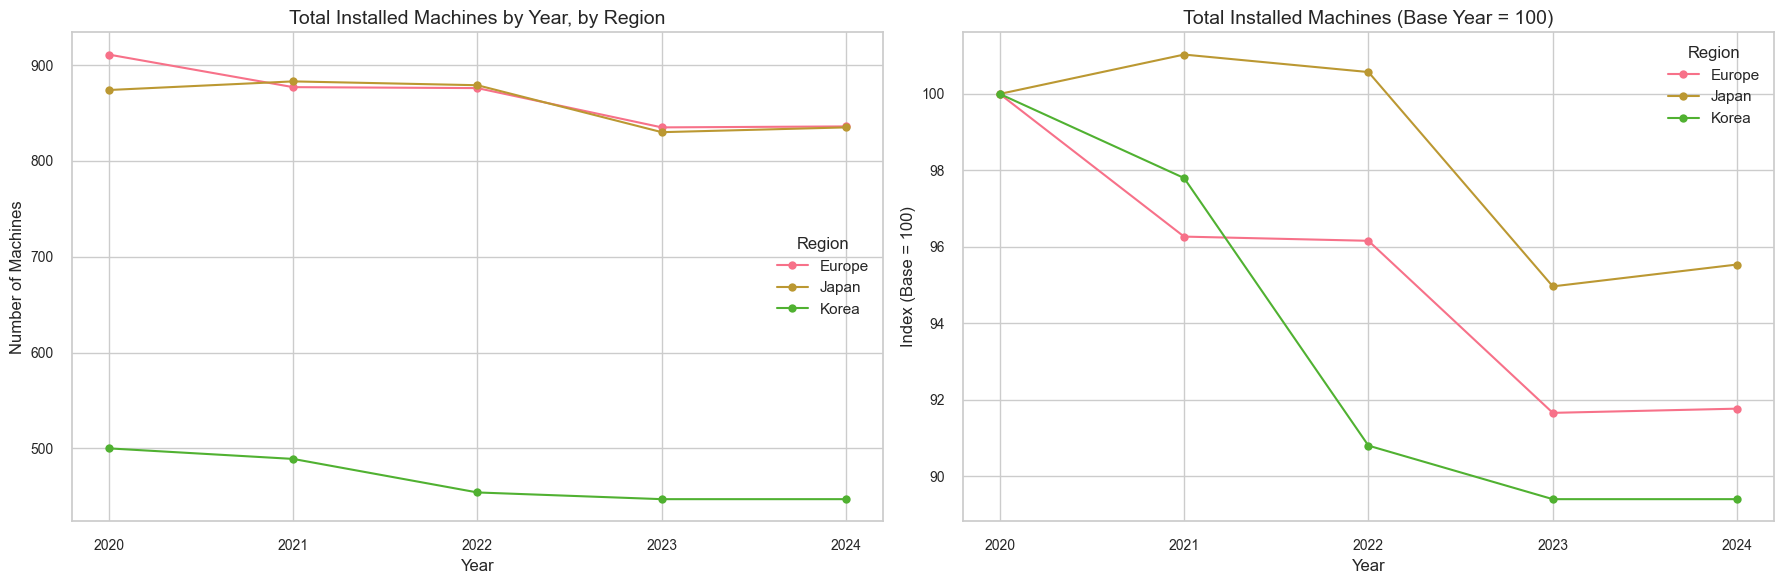

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (Left) Totals (absolute)
ax = axes[0]

for reg in regions:
    snap_reg = summarize_data(eda_df, region=reg, freq="Annually", verbose=False)
    ax.plot(
        snap_reg.index.astype(str),
        snap_reg["Total"],
        marker="o",
        label=reg,
    )

ax.set_title("Total Installed Machines by Year, by Region", fontsize=TITLE_FONTSIZE)
ax.set_xlabel("Year", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Number of Machines", fontsize=LABEL_FONTSIZE)
ax.tick_params(labelsize=TICK_FONTSIZE)
ax.legend(title="Region")
ax.grid(True)

# (Right) Indexed totals (base year = 100)
ax = axes[1]

for reg in regions:
    snap_reg = summarize_data(eda_df, region=reg, freq="Annually", verbose=False)
    base_value = snap_reg["Total"].iloc[0]
    snap_reg["Index"] = (snap_reg["Total"] / base_value) * 100

    ax.plot(
        snap_reg.index.astype(str),
        snap_reg["Index"],
        marker="o",
        label=reg,
    )

ax.set_title("Total Installed Machines (Base Year = 100)", fontsize=TITLE_FONTSIZE)
ax.set_xlabel("Year", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Index (Base = 100)", fontsize=LABEL_FONTSIZE)
ax.tick_params(labelsize=TICK_FONTSIZE)
ax.legend(title="Region")
ax.grid(True)

plt.tight_layout()
plt.show()

#### 8.1.3: Dashboard of Installed Machines Overview by Region

This figure summarizes key machine-installation patterns for Europe across the 2020–2024 period.

- **(Left) Total Machines Over Time:**  
  Annual totals show a gradual decline in installed machines from 2020 to 2023, followed by a slight increase in 2024. This provides a high-level view of region-wide capacity changes over the sample period.

- **(Center) Top 10 Field Offices (Average Totals):**  
  The bar chart highlights the field offices with the highest average machine counts across all years. KAISERSLAUTERN and VILSECK clearly dominate the region, indicating concentrated installation activity in a small number of locations.

- **(Right) Machine Composition (2024):**  
  The 2024 snapshot shows that Slots comprise the overwhelming majority of machines (≈87%), with ACM, ITC, and FRS representing much smaller shares. This composition illustrates the limited diversity of machine types in the most recent year.

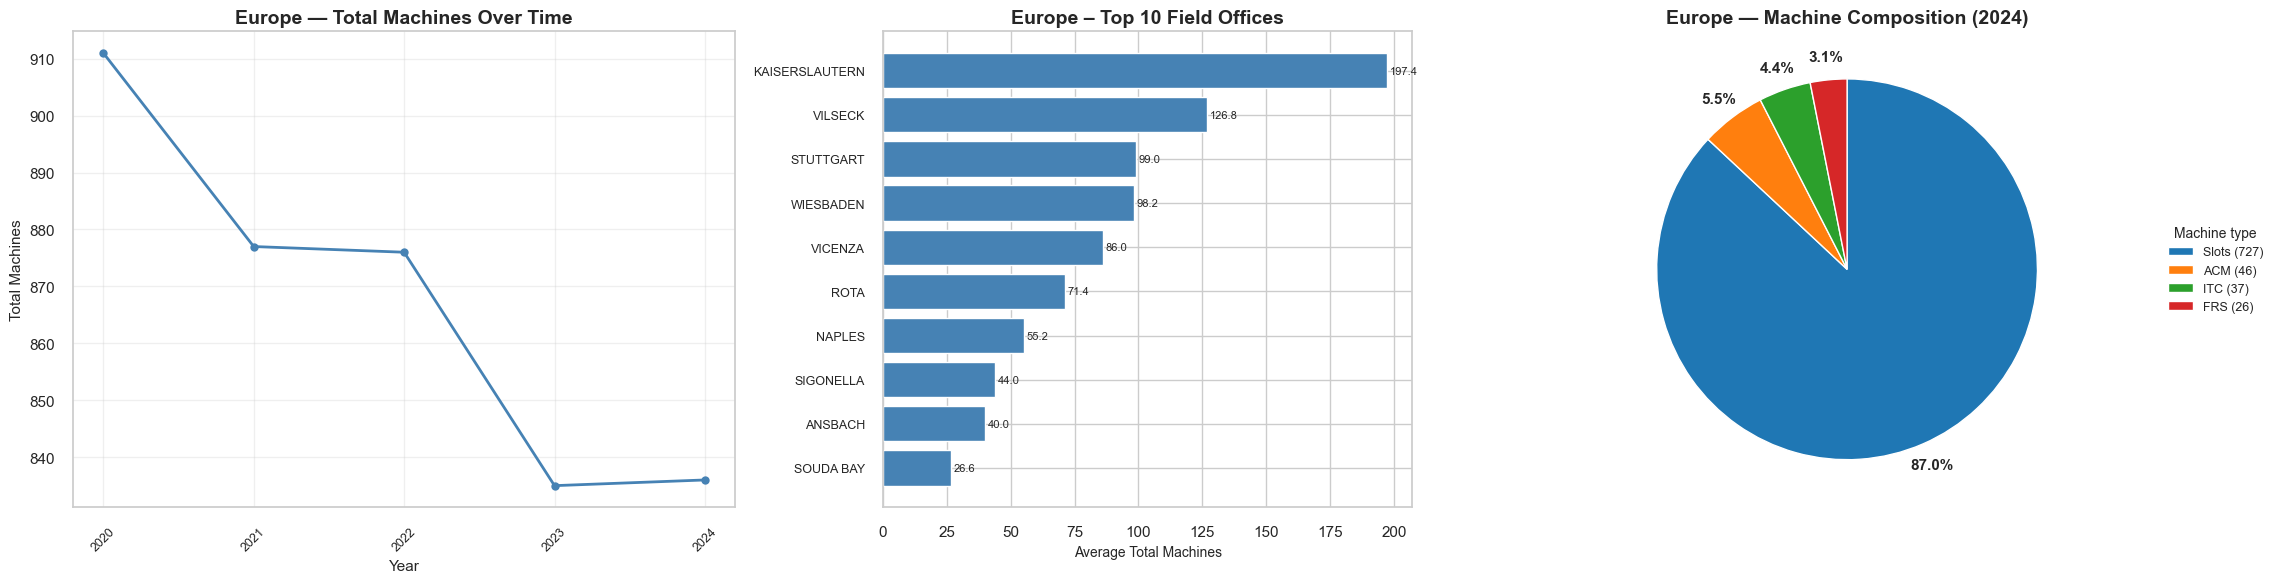

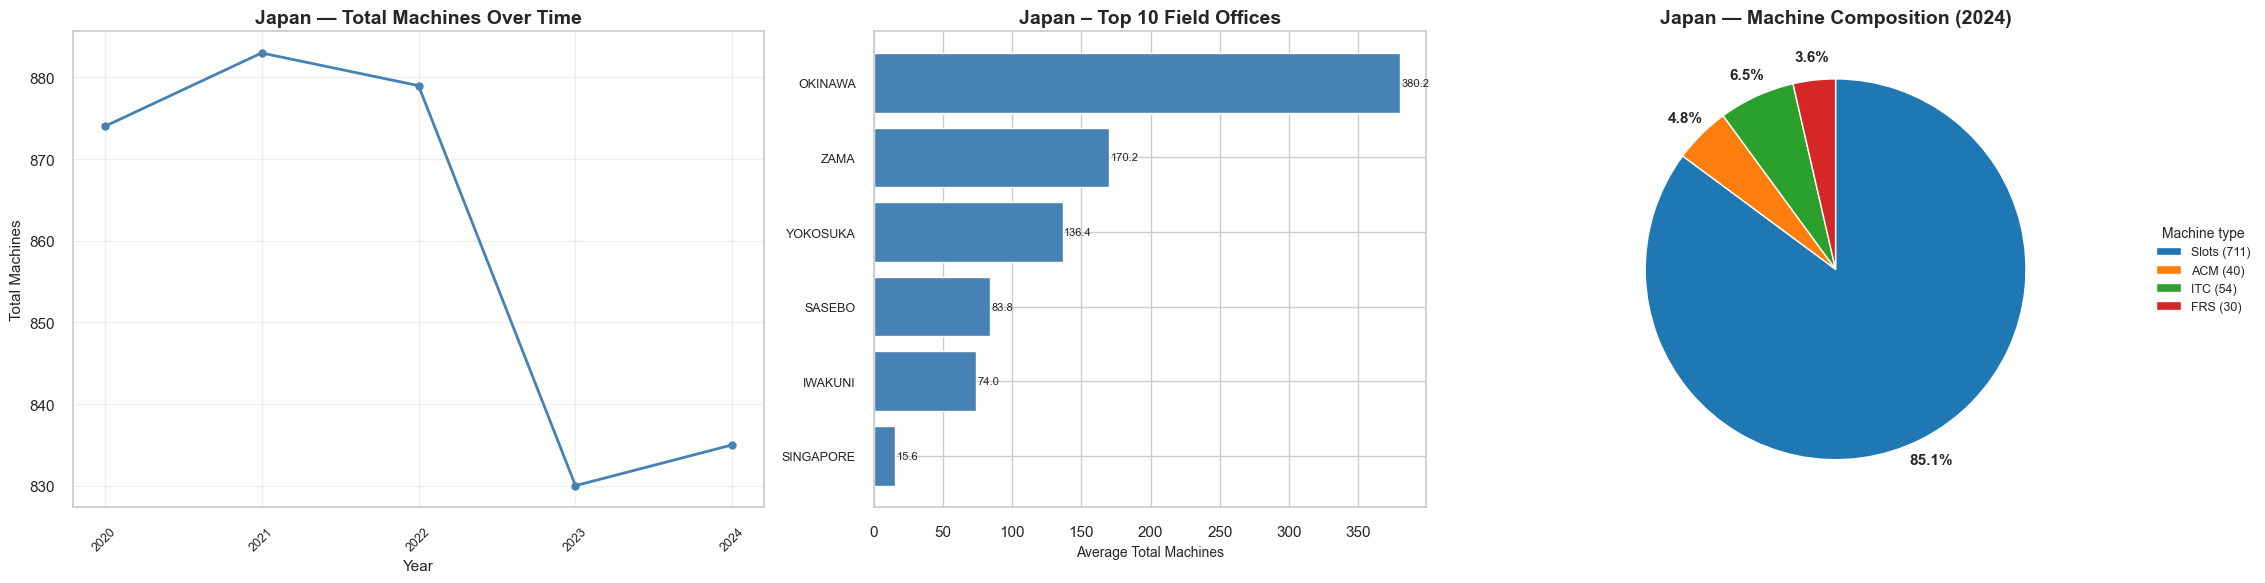

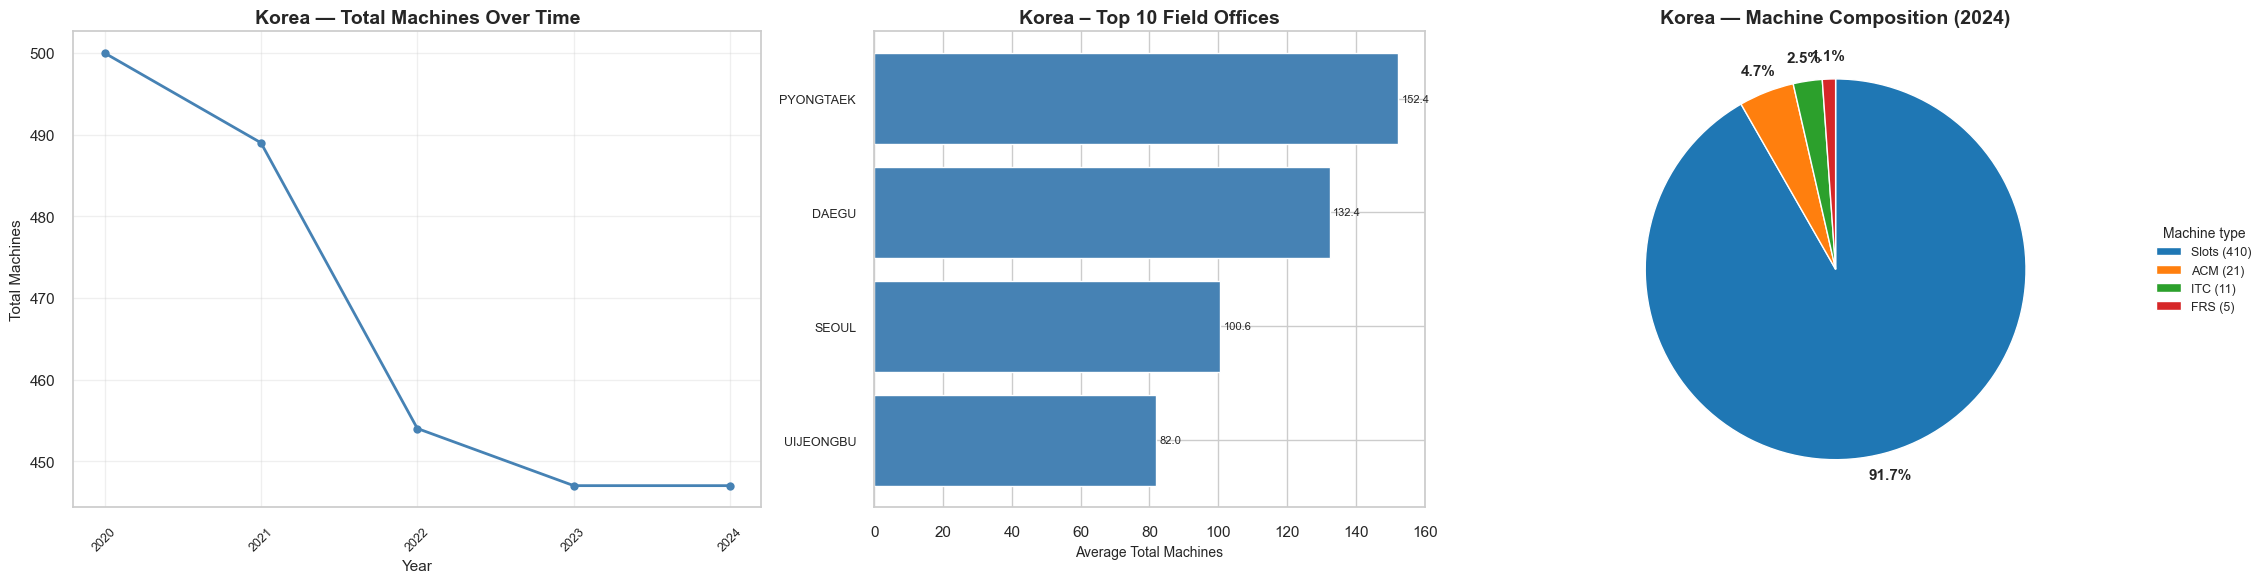

In [231]:
dashboard_region(eda_df, "Europe")
dashboard_region(eda_df, "Japan")
dashboard_region(eda_df, "Korea")

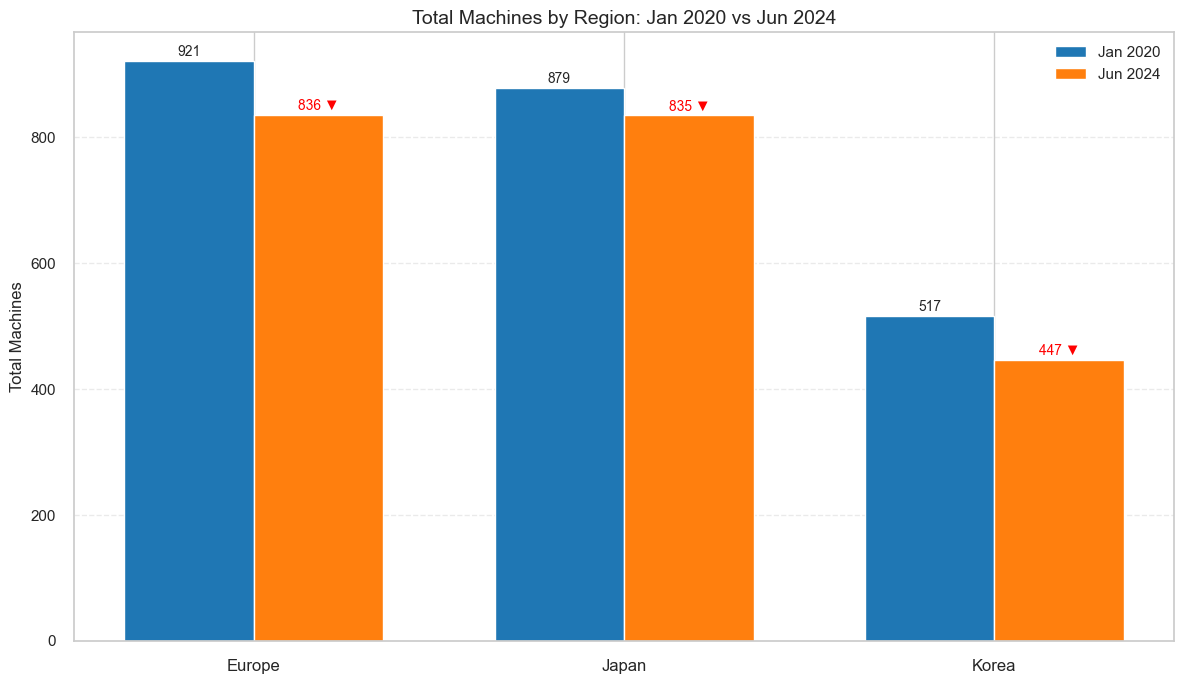

In [232]:
snap_2020 = get_snapshot(eda_df, 2020, 1)
snap_2024 = get_snapshot(eda_df, 2024, 6)

jan2020_vals = [snap_2020.get(reg, 0) for reg in regions]
jun2024_vals = [snap_2024.get(reg, 0) for reg in regions]

x = np.arange(len(regions))
width = 0.35

plt.figure(figsize=(12, 7))

bars1 = plt.bar(x - width / 2, jan2020_vals, width, label="Jan 2020", color="#1f77b4")
bars2 = plt.bar(x + width / 2, jun2024_vals, width, label="Jun 2024", color="#ff7f0e")

for bar, val in zip(bars1, jan2020_vals):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{val}",
        ha="center",
        fontsize=10,
    )

for bar, val, region in zip(bars2, jun2024_vals, regions):
    delta = val - snap_2020.get(region, 0)
    if delta < 0:
        label = f"{val} ▼"
        color = "red"
    elif delta > 0:
        label = f"{val} ▲"
        color = "green"
    else:
        label = f"{val} →"
        color = "black"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        label,
        ha="center",
        fontsize=10,
        color=color,
    )

plt.xticks(x, regions, fontsize=12)
plt.ylabel("Total Machines", fontsize=12)
plt.title("Total Machines by Region: Jan 2020 vs Jun 2024", fontsize=14)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


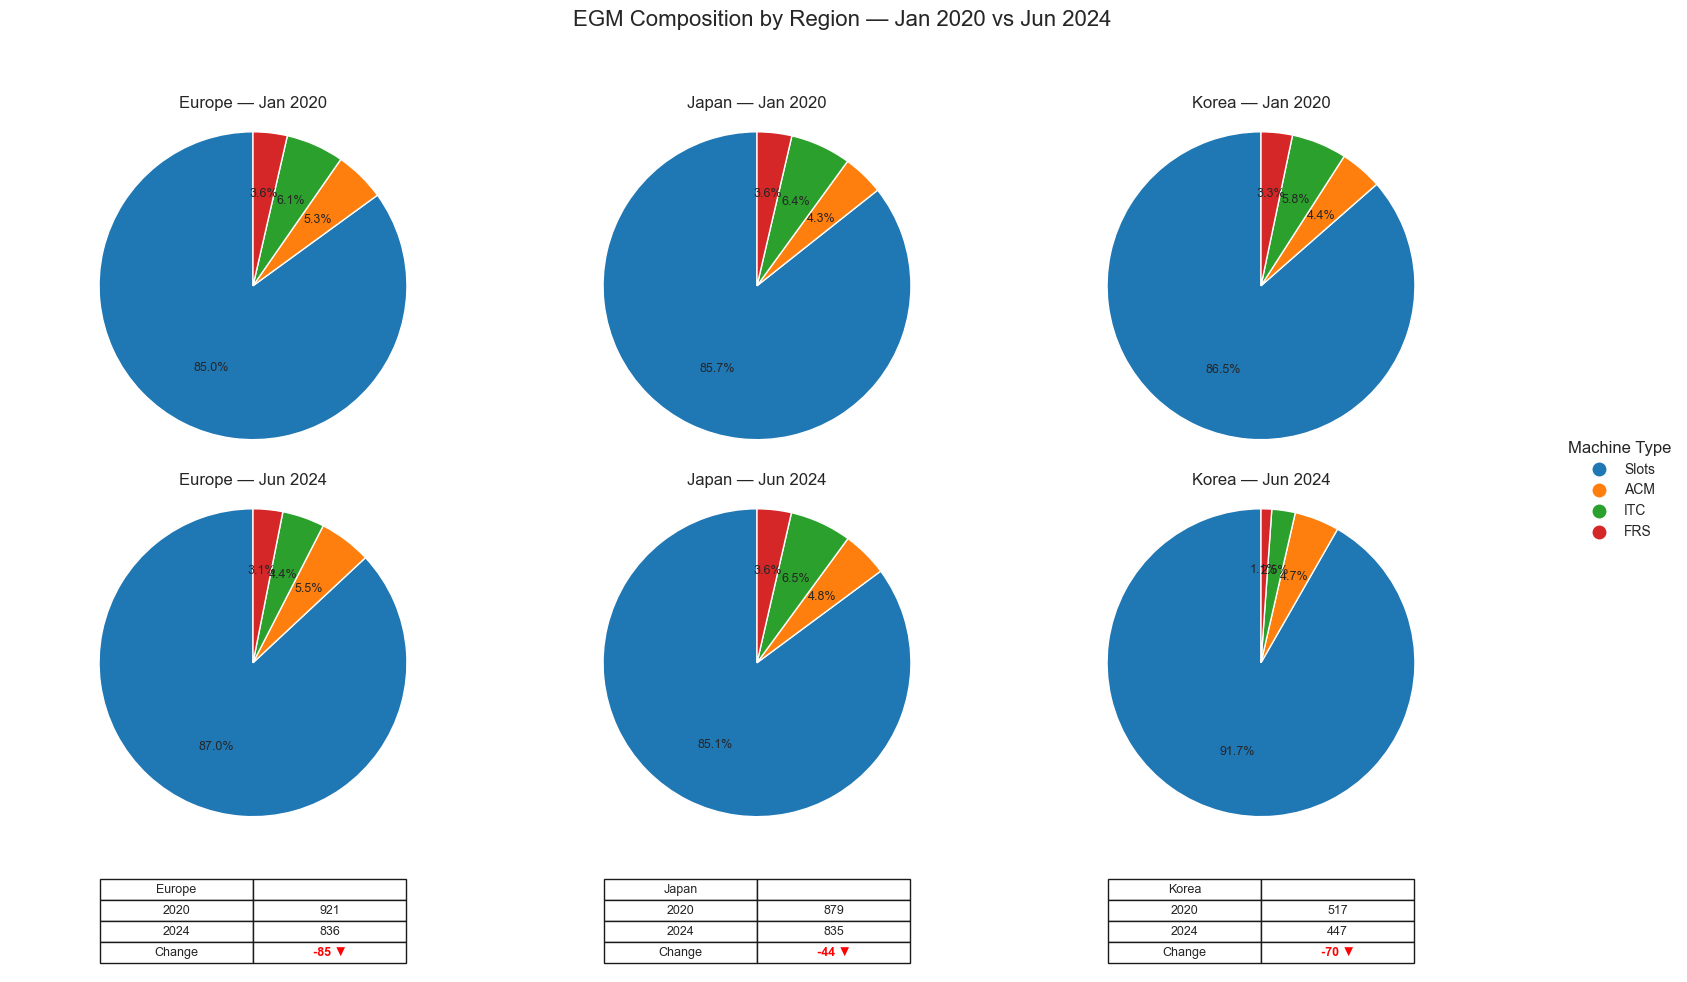

In [233]:
snap2020 = get_region_snapshot(eda_df, 2020, 1)
snap2024 = get_region_snapshot(eda_df, 2024, 6)

fig = plt.figure(figsize=(17, 10))
gs = fig.add_gridspec(3, 3, height_ratios=[3, 3, 0.9])

# Row 1: 2020 pies
for i, region in enumerate(regions):
    ax = fig.add_subplot(gs[0, i])
    vals = snap2020.loc[region, machine_cols].values

    ax.pie(
        vals,
        autopct="%1.1f%%",
        labels=None,
        colors=colors,
        startangle=90,
        textprops={"fontsize": 9},
    )
    ax.set_title(f"{region} — Jan 2020", fontsize=12)
    ax.axis("equal")

# Row 2: 2024 pies
for i, region in enumerate(regions):
    ax = fig.add_subplot(gs[1, i])
    vals = snap2024.loc[region, machine_cols].values

    ax.pie(
        vals,
        autopct="%1.1f%%",
        labels=None,
        colors=colors,
        startangle=90,
        textprops={"fontsize": 9},
    )
    ax.set_title(f"{region} — Jun 2024", fontsize=12)
    ax.axis("equal")

# Shared legend
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=c,
        markersize=10,
        label=col,
    )
    for c, col in zip(colors, machine_cols)
]
fig.legend(
    handles,
    machine_cols,
    title="Machine Type",
    bbox_to_anchor=(0.92, 0.5),
    loc="center left",
    fontsize=10,
)

# Row 3: Mini-tables
for i, region in enumerate(regions):
    ax = fig.add_subplot(gs[2, i])
    ax.axis("off")

    total20 = int(snap2020.loc[region].sum())
    total24 = int(snap2024.loc[region].sum())
    delta = total24 - total20

    if delta > 0:
        arrow = "▲"
        color = "green"
    elif delta < 0:
        arrow = "▼"
        color = "red"
    else:
        arrow = "→"
        color = "black"

    table_data = [
        ["2020", f"{total20:,}"],
        ["2024", f"{total24:,}"],
        ["Change", f"{delta:+,} {arrow}"],
    ]

    tbl = ax.table(
        cellText=table_data,
        colLabels=[f"{region}", ""],
        cellLoc="center",
        loc="center",
        colWidths=[0.35, 0.35],
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(0.9, 1.1)

    change_cell = tbl[(3, 1)]
    change_cell.get_text().set_color(color)
    change_cell.get_text().set_fontweight("bold")

plt.suptitle("EGM Composition by Region — Jan 2020 vs Jun 2024", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.90, 0.95])
plt.show()


In [234]:
def plot_all_machine_types_grid(df: pd.DataFrame):
    """
    2×2 grid of grouped bar charts (Slots, ACM, ITC, FRS).
    Y-axis is capped at 100 for ACM, ITC, FRS for readability.
    """

    machine_types = ["Slots", "ACM", "ITC", "FRS"]

    region_colors = {
        "Europe": "#1f77b4",
        "Japan":  "#ff7f0e",
        "Korea":  "#2ca02c",
    }
    regions = list(region_colors.keys())

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    for ax, machine_col in zip(axes, machine_types):

        snap = yearly_region_snapshot(df, machine_col)
        years = sorted(snap["Year"].unique())

        x = np.arange(len(years))
        width = 0.22

        for i, reg in enumerate(regions):

            vals = [
                snap.loc[(snap["Year"] == yr) & (snap["Region"] == reg), machine_col].iloc[0]
                if not snap[(snap["Year"] == yr) & (snap["Region"] == reg)].empty
                else 0
                for yr in years
            ]

            offset = (i - 1) * width
            bars = ax.bar(x + offset, vals, width, color=region_colors[reg], label=reg)

            # Add machine count labels (above bar)
            for bar, v in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (3 if machine_col=="Slots" else 1),
                    f"{int(v):,}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

        ax.set_xticks(x)
        ax.set_xticklabels(years)
        ax.set_title(f"Total {machine_col} Machines by Region & Year", fontsize=12)
        ax.set_xlabel("Year", fontsize=10)
        ax.set_ylabel("Number of Electronic Gaming Machines", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        # Correct Y-axis rescaling for ACM / ITC / FRS
        if machine_col in ["ACM", "ITC", "FRS"]:
            ax.set_ylim(0, 80)  # cap at 100 machines

    # Legend for regions
    handles = [
        plt.Line2D([0], [0], marker="s", color="w",
                   label=reg, markerfacecolor=col, markersize=10)
        for reg, col in region_colors.items()
    ]

    fig.legend(
        handles=handles,
        title="Region",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left"
    )

    plt.tight_layout()
    plt.show()
    
    plot_all_machine_types_grid(eda_df)

#### 8.1.5 Bar Plot of Total Gambling Machines Installed by Machine Type

Using the cleaned Format 1 dataset, we take the latest available reporting snapshot (i.e., the maximum `Reporting_Date` in the data) and sum the counts of each machine 
type (`Slots`, `ACM`, `ITC`, `FRS`) across all field offices. This bar chart shows how the installed base of gambling machines is distributed across machine types at 
the most recent point in time.

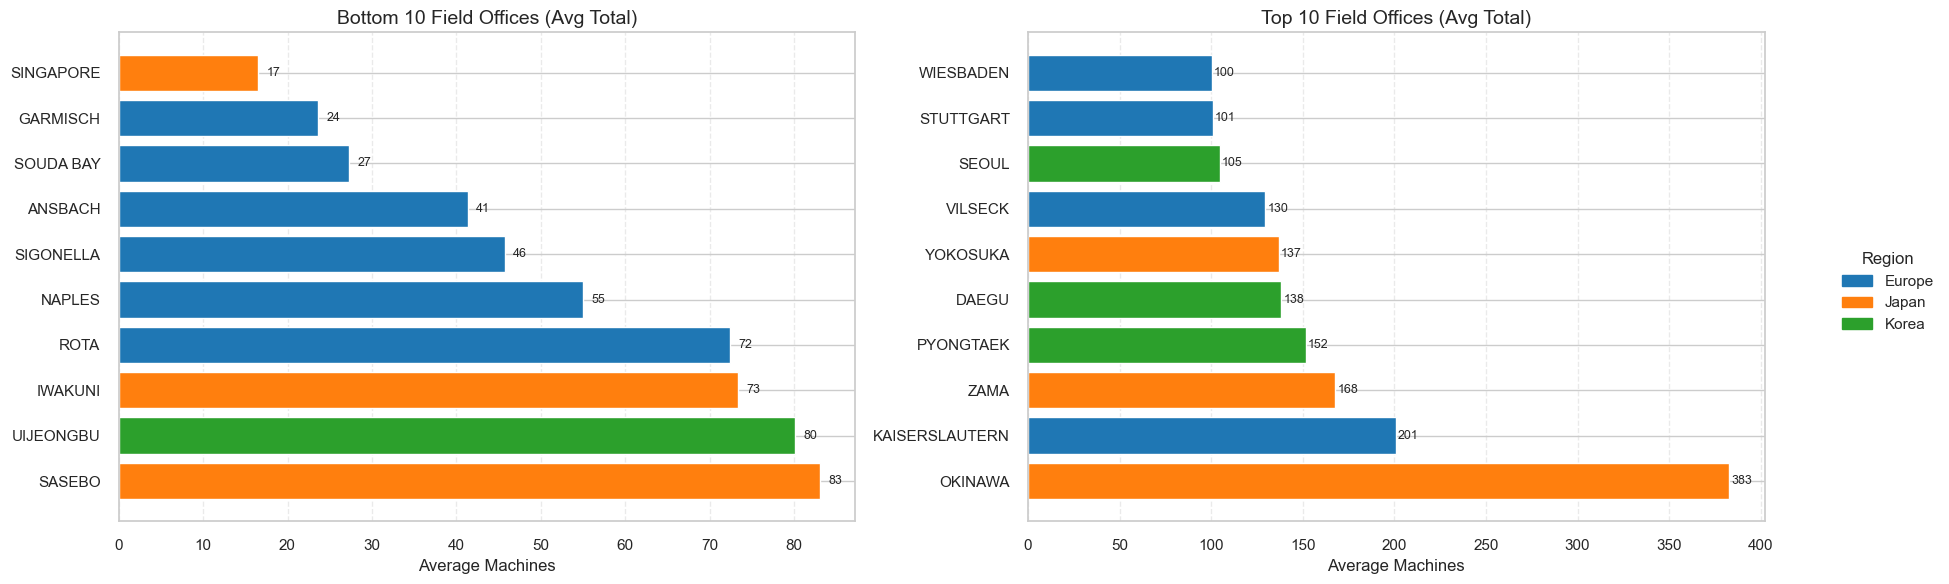

In [ ]:
def plot_top_bottom_bases(df: pd.DataFrame, n: int = 10) -> None:
    """
    Plot the bottom N and top N field offices by average Total machines.

    Each bar is color-coded by region, includes value labels,
    and the figure includes a region legend on the right side.
    """
    # Region → color mapping
    color_map = {
        "Europe": "#1f77b4",
        "Japan":  "#ff7f0e",
        "Korea":  "#2ca02c",
    }

    # Average machine totals per field office (with region)
    avg_totals = (
        df.groupby(["Field_Office_Name", "Region"])["Total"]
          .mean()
          .reset_index()
          .sort_values("Total")
    )

    bottom = avg_totals.head(n)
    top = avg_totals.tail(n)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)

    # Bottom N field offices
    ax = axes[0]
    bottom_sorted = bottom.sort_values("Total")

    colors = bottom_sorted["Region"].map(color_map)
    bars = ax.barh(
        bottom_sorted["Field_Office_Name"],
        bottom_sorted["Total"],
        color=colors,
    )

    for bar, val in zip(bars, bottom_sorted["Total"]):
        ax.text(
            val + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}",
            va="center",
            fontsize=9,
        )

    ax.set_title(f"Bottom {n} Field Offices (Avg Total)", fontsize=14)
    ax.set_xlabel("Average Machines", fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.invert_yaxis()

    # Top N field offices
    ax = axes[1]
    top_sorted = top.sort_values("Total")

    colors = top_sorted["Region"].map(color_map)
    bars = ax.barh(
        top_sorted["Field_Office_Name"],
        top_sorted["Total"],
        color=colors,
    )

    for bar, val in zip(bars, top_sorted["Total"]):
        ax.text(
            val + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}",
            va="center",
            fontsize=9,
        )

    ax.set_title(f"Top {n} Field Offices (Average Total)", fontsize=14)
    ax.set_xlabel("Average Machines", fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.invert_yaxis()

    # Legend on right side
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color_map[reg], label=reg)
        for reg in color_map
    ]

    fig.legend(
        handles=legend_handles,
        title="Region",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=11,
        title_fontsize=12,
    )

    plt.tight_layout()
    plt.show()
    
plot_top_bottom_bases(eda_df, n=10)

##### 8.1.1 Pie Plot of Total Gambling Machines Installed by Region

This visualization shows how the total number of installed gambling machines is distributed across the three reporting regions (Europe, Japan, Korea) aggregates all field offices in the most recent reporting year, giving the latest overall regional footprint of the machine network.

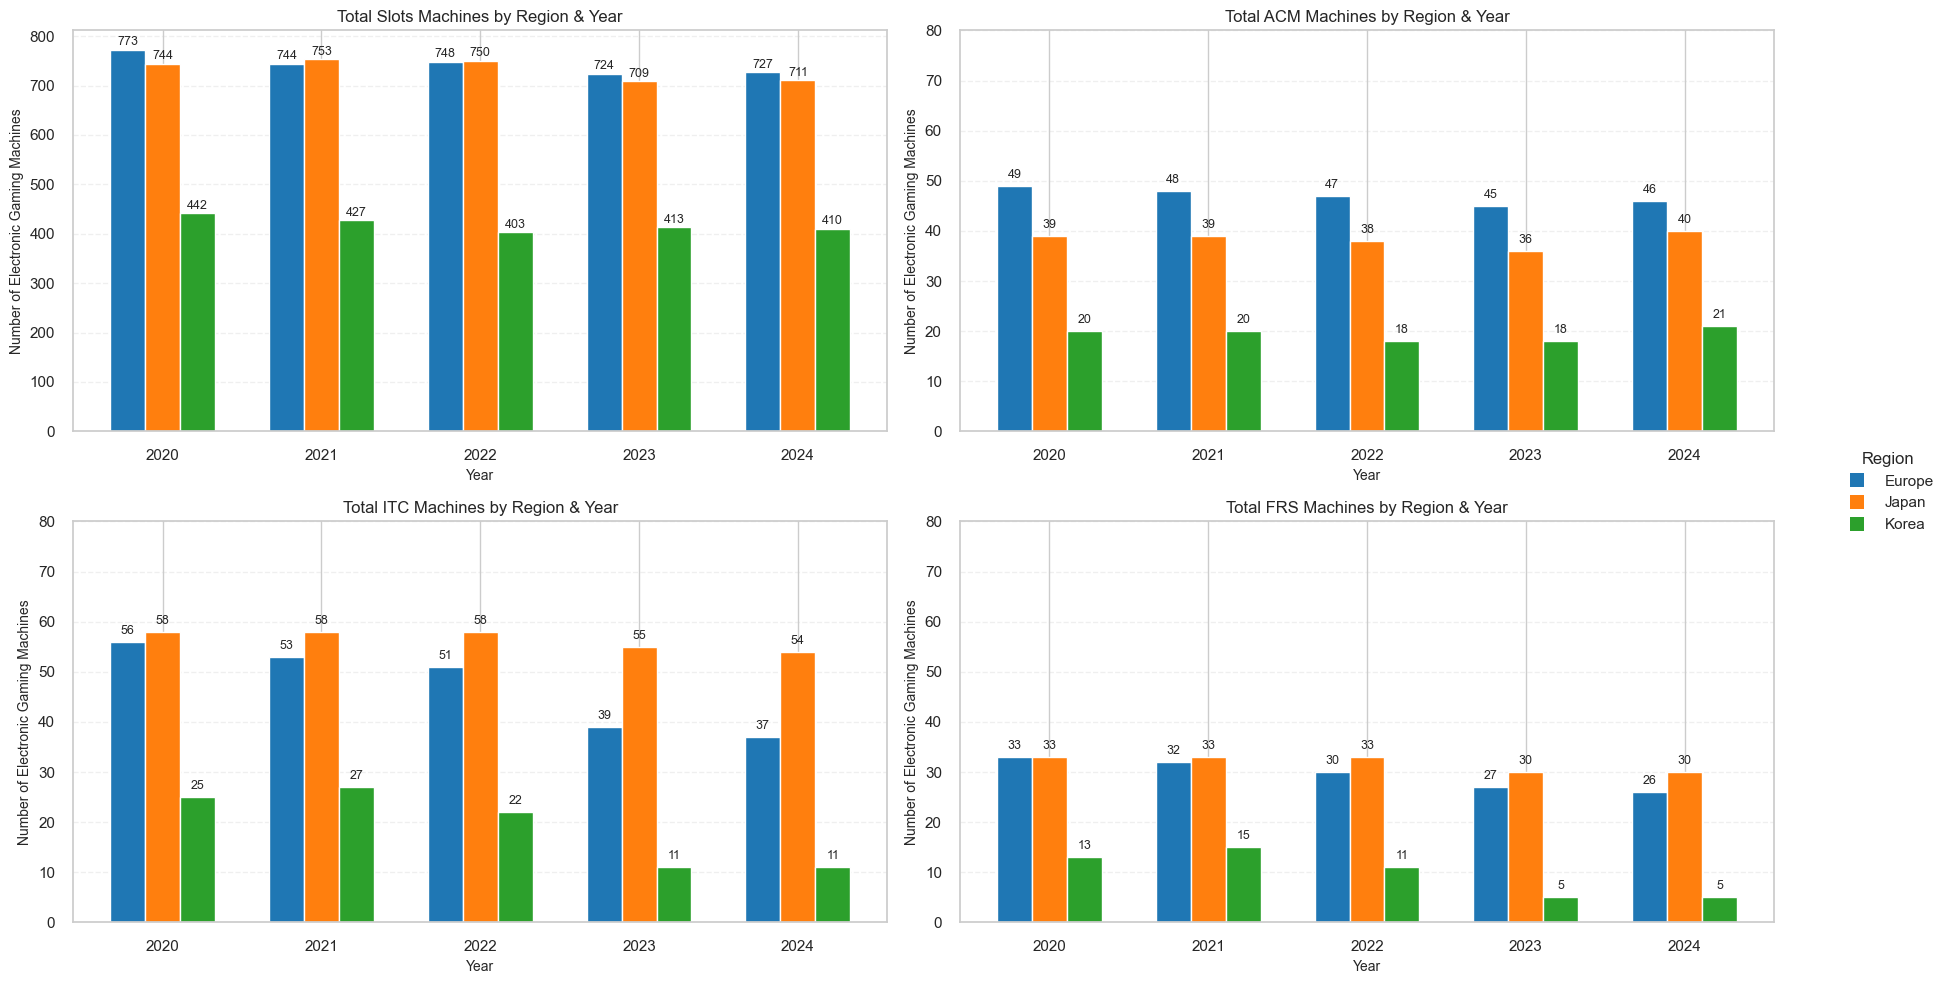

In [237]:
def plot_all_machine_types_grid(df: pd.DataFrame):
    """
    2×2 grid of grouped bar charts (Slots, ACM, ITC, FRS).
    Y-axis is capped at 100 for ACM, ITC, FRS for readability.
    """

    machine_types = ["Slots", "ACM", "ITC", "FRS"]

    region_colors = {
        "Europe": "#1f77b4",
        "Japan":  "#ff7f0e",
        "Korea":  "#2ca02c",
    }
    regions = list(region_colors.keys())

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()

    for ax, machine_col in zip(axes, machine_types):

        snap = yearly_region_snapshot(df, machine_col)
        years = sorted(snap["Year"].unique())

        x = np.arange(len(years))
        width = 0.22

        for i, reg in enumerate(regions):

            vals = [
                snap.loc[(snap["Year"] == yr) & (snap["Region"] == reg), machine_col].iloc[0]
                if not snap[(snap["Year"] == yr) & (snap["Region"] == reg)].empty
                else 0
                for yr in years
            ]

            offset = (i - 1) * width
            bars = ax.bar(x + offset, vals, width, color=region_colors[reg], label=reg)

            # Add machine count labels (above bar)
            for bar, v in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (3 if machine_col=="Slots" else 1),
                    f"{int(v):,}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

        ax.set_xticks(x)
        ax.set_xticklabels(years)
        ax.set_title(f"Total {machine_col} Machines by Region & Year", fontsize=12)
        ax.set_xlabel("Year", fontsize=10)
        ax.set_ylabel("Number of Electronic Gaming Machines", fontsize=10)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        # Correct Y-axis rescaling for ACM / ITC / FRS
        if machine_col in ["ACM", "ITC", "FRS"]:
            ax.set_ylim(0, 80)  # cap at 100 machines

    # Legend for regions
    handles = [
        plt.Line2D([0], [0], marker="s", color="w",
                   label=reg, markerfacecolor=col, markersize=10)
        for reg, col in region_colors.items()
    ]

    fig.legend(
        handles=handles,
        title="Region",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left"
    )

    plt.tight_layout()
    plt.show()

plot_all_machine_types_grid(eda_df)

##### 8.1.2 Pie Plot of Total Gambling Machines Installed by Region and Machine Type

##### 8.1.3 Timeseries Plot of Total Gambling  Machines Installed by Region and Frequency

##### 8.1.4 Indexed Timeseries Plot of Total Gambling  Machines Installed by Region and Frequency

##### 8.1.5 Bar Plot of Total Gambling Machines Installed by Machine Type

##### 8.1.6 Bar Plot of Net Change in Total Gambling Machines by Frequency

##### 8.1.7 Bubble Map of Machine Type Shares vs Total Shares by Frequency and Region

##### 7.2.2 Plots and Visualization by Time

After preparing the dataset by converting dates, parsing machine counts, and calculating total machines per field office, we next summarize the data by Year and by Quarter.

It is important to note that:
- the totals shown for each year are not the `sum` of all monthly reports.
- instead, each field office typically reports once per month, and the dataset contains the most recent snapshot available for each reporting period.
- therefore, the `Total` for a given year or quarter reflects the snapshot from the final reporting month within that period, not a cumulative annual `sum`.

This aligns with the structure of the asset reports: they present installed machine counts at the time of reporting, not incremental additions. As a result, the aggregated yearly or quarterly totals represent the state of deployed machines, not cumulative machine installations throughout the year.

#### 7.1 Quarterly Trends in Installed Machines  

We aggregate machine totals (`Slots`, `ACM`, `ITC`, `FRS`) by quarter to visualize how installed machine counts evolve across the full fiscal years 2020 to 2024 period. This reveals the seasonality and growth patterns of different machine types.  

### Format 4

In [238]:
print("Shape:", ar4.shape)
ar4.head()

Shape: (78927, 22)


,Loc,PLACE,REGION,SVC,Asset,SerialNum,Type,Desc,Aquire,Effective,...,MFG,LNAME,FONUM,FOSHORT,Cat,Year,Age,FY,lat,long
0,194.0,Floor,Europe,Army,337961.0,337961-B170503048,3617.0,BAL WAVE ULT FE OLVERA ST MLP,11/15/2017,2/16/2018,...,BAL,IRISH PUB,2,KAISERSLAUTERN,NaN,2017,0.0,2020.0,49.440066,7.749126
1,194.0,Floor,Europe,Army,337198.0,337198-XAR671628,1371.0,AIN/A560 MULTI WIN2 (SAP-MJP),11/30/2016,1/27/2017,...,AIN,IRISH PUB,2,KAISERSLAUTERN,NaN,2016,0.0,2020.0,49.440066,7.749126
2,194.0,Floor,Europe,Army,337199.0,337199-XAR671629,1373.0,AIN A560 MULTI WIN4 (SAP-MJP),11/30/2016,1/27/2017,...,AIN,IRISH PUB,2,KAISERSLAUTERN,NaN,2016,0.0,2020.0,49.440066,7.749126
3,194.0,Floor,Europe,Army,337200.0,337200-XAR671630,1375.0,AIN/A560 MULTI WIN5 (SAP-MJP),11/30/2016,1/27/2017,...,AIN,IRISH PUB,2,KAISERSLAUTERN,NaN,2016,0.0,2020.0,49.440066,7.749126
4,194.0,Floor,Europe,Army,337201.0,337201-XAR671631,1377.0,AIN/A560 MULTI WIN13 (SAP-MJP),11/30/2016,1/27/2017,...,AIN,IRISH PUB,2,KAISERSLAUTERN,NaN,2016,0.0,2020.0,49.440066,7.749126


In [239]:
#Data Cleaning and Feature Engineering
ar4["FY_int"] = pd.to_numeric(ar4["FY"], errors="coerce").astype("Int64")

ar4["Aquire_dt"] = pd.to_datetime(ar4["Aquire"], errors="coerce")
ar4["Year_acquire"] = ar4["Aquire_dt"].dt.year


ar4["Type_str"] = ar4["Type"].astype(str)


def extract_cat_from_foshort(x):
    x = str(x).upper().strip()
    if x.endswith(" SLOT"):
        return "SLOT"
    if x.endswith(" FRS"):
        return "FRS"
    if "ACM" in x or "ITC" in x:
        return "ACM/ITC"
    return None  


foshort_cat = ar4["FOSHORT"].apply(extract_cat_from_foshort)



def clean_base(x):
    x = str(x).strip()
    x = x.replace(" SLOT", "").replace(" FRS", "")
    x = x.replace(" ACM/ITC", "").replace(" ACM", "").replace(" ITC", "")
    return x.strip()

ar4["Base_clean"] = ar4["FOSHORT"].astype(str).apply(clean_base)

ar4["Base_clean"] = ar4["Base_clean"].str.replace(r"^SOUDA$", "SOUDA BAY", regex=True, case=False)

original_cat = ar4["Cat"].astype(str).str.strip().str.upper().replace("NAN", None)

ar4["Cat_clean"] = foshort_cat.copy()

ar4["Cat_clean"] = ar4["Cat_clean"].fillna(original_cat)

ar4["Cat_clean"] = ar4["Cat_clean"].replace("NAN", pd.NA)

ar4[["FOSHORT", "Base_clean", "Cat", "Cat_clean"]].head()

,FOSHORT,Base_clean,Cat,Cat_clean
0,KAISERSLAUTERN,KAISERSLAUTERN,NaN,None
1,KAISERSLAUTERN,KAISERSLAUTERN,NaN,None
2,KAISERSLAUTERN,KAISERSLAUTERN,NaN,None
3,KAISERSLAUTERN,KAISERSLAUTERN,NaN,None
4,KAISERSLAUTERN,KAISERSLAUTERN,NaN,None


In [240]:
print("Category (Cat_clean) distribution:")
print(ar4["Cat_clean"].value_counts(dropna=False).head(10))

print("\nFiscal years present:")
print(ar4["FY_int"].value_counts().sort_index())

print("\nSample of Base vs Category:")
print(ar4[["Base_clean", "Cat_clean"]].drop_duplicates().head(15))


Category (Cat_clean) distribution:
Cat_clean
SLOT       60817
None        8406
ACM/ITC     7345
FRS         2359
Name: count, dtype: int64

Fiscal years present:
FY_int
2020    20666
2021     6831
2022    28930
2023    22267
Name: count, dtype: Int64

Sample of Base vs Category:
          Base_clean Cat_clean
0     KAISERSLAUTERN      None
136        STUTTGART      None
245          VICENZA      None
266          VILSECK      None
348          ANSBACH      None
392            SEOUL      None
532        UIJEONGBU      None
606        PYONGTAEK      None
634            DAEGU      None
737             ZAMA      None
821          OKINAWA      None
1121         IWAKUNI      None
1162       WIESBADEN      None
1370        GARMISCH      None
1449          NAPLES      None


In [241]:
# Category-Level Trend Over Time (SLOT vs FRS vs ACM/ITC)
main_cats = ["SLOT", "FRS", "ACM/ITC"]

cat_filtered = ar4[
    ar4["Cat_clean"].isin(main_cats) & ar4["FY_int"].notna()
]

cat_year = (
    cat_filtered
    .groupby(["Cat_clean", "FY_int"])
    .size()
    .reset_index(name="count")
)

cat_year

,Cat_clean,FY_int,count
0,ACM/ITC,2020,1377
1,ACM/ITC,2021,740
2,ACM/ITC,2022,3107
3,ACM/ITC,2023,2099
4,FRS,2020,450
5,FRS,2021,236
6,FRS,2022,1009
7,FRS,2023,657
8,SLOT,2020,10838
9,SLOT,2021,5855


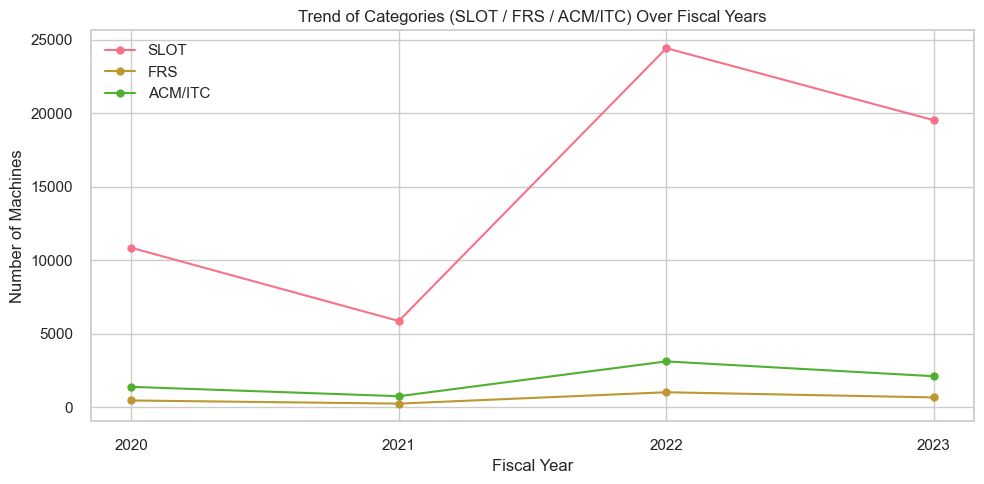

In [242]:
# Plotting the trends
plt.figure(figsize=(10, 5))

for cat in main_cats:
    sub = cat_year[cat_year["Cat_clean"] == cat]
    if sub.empty:
        continue
    plt.plot(sub["FY_int"], sub["count"], marker="o", label=cat)

plt.xlabel("Fiscal Year")
plt.ylabel("Number of Machines")
plt.title("Trend of Categories (SLOT / FRS / ACM/ITC) Over Fiscal Years")
plt.xticks(sorted(cat_year["FY_int"].dropna().unique()))
plt.legend()
plt.tight_layout()
plt.show()


In [243]:
#Trend Lines for Top Machine Types
def most_common_cat(x):
    x_nonnull = x.dropna()
    if x_nonnull.empty:
        return "UNKNOWN"     # fallback when no category is available for this type
    return x_nonnull.value_counts().idxmax()

type_cat_map = (
    ar4.groupby("Type_str")["Cat_clean"]
      .apply(most_common_cat)
      .to_dict()
)


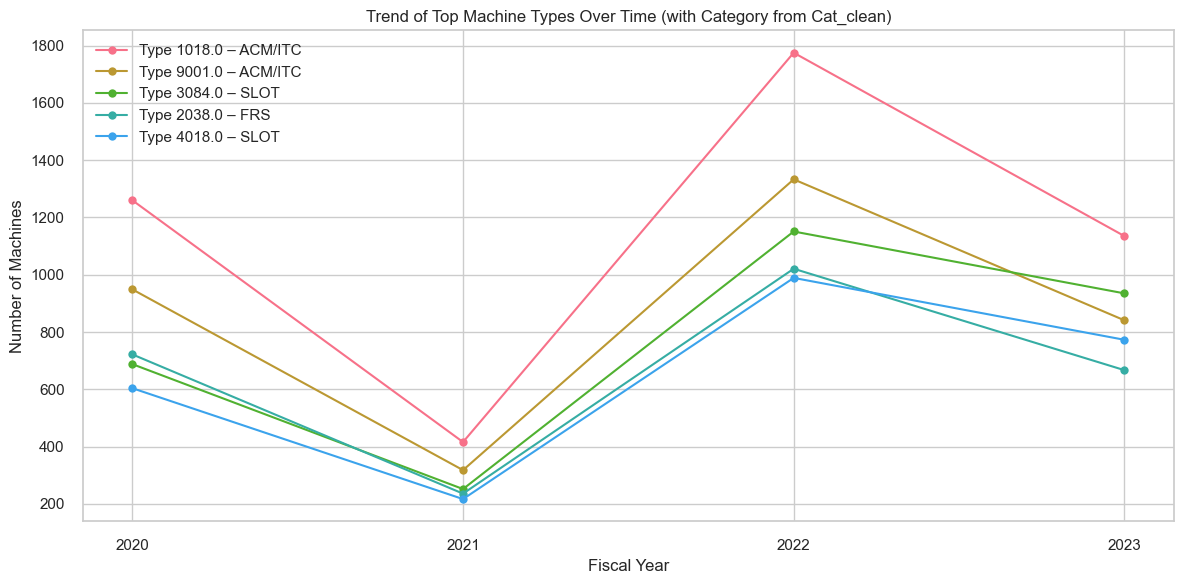

In [244]:
# Build type-year table across all bases
type_year = (
    ar4.dropna(subset=["FY_int"])
      .groupby(["Type_str", "FY_int"])
      .size()
      .reset_index(name="count")
)

# Select TOP N machine types overall
TOP_N = 5
top_types = (
    type_year.groupby("Type_str")["count"]
             .sum()
             .nlargest(TOP_N)
             .index
)

plot_data = type_year[type_year["Type_str"].isin(top_types)]


plt.figure(figsize=(12, 6))

for t in top_types:
    sub = plot_data[plot_data["Type_str"] == t]
    cat = type_cat_map.get(t, "UNKNOWN")
    label = f"Type {t} – {cat}"
    plt.plot(sub["FY_int"], sub["count"], marker="o", label=label)

plt.xlabel("Fiscal Year")
plt.ylabel("Number of Machines")
plt.title("Trend of Top Machine Types Over Time (with Category from Cat_clean)")
plt.xticks(sorted(plot_data["FY_int"].dropna().unique()))
plt.legend()
plt.tight_layout()
plt.show()


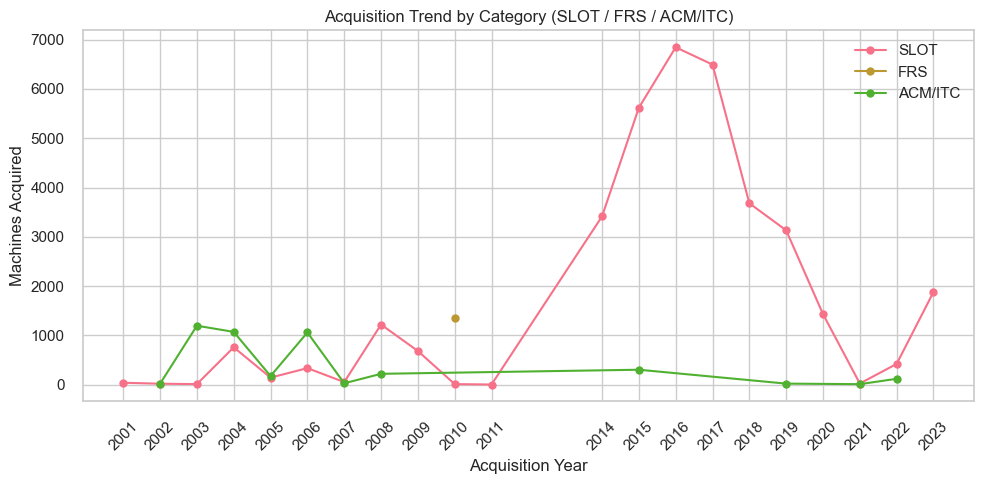

In [245]:
# Acquisition-Based Category Trend
acq_cat = (
    ar4.dropna(subset=["Year_acquire"])  
      .groupby(["Cat_clean", "Year_acquire"])
      .size()
      .reset_index(name="count")
)

acq_cat_main = acq_cat[acq_cat["Cat_clean"].isin(main_cats)]

plt.figure(figsize=(10, 5))

for cat in main_cats:
    sub = acq_cat_main[acq_cat_main["Cat_clean"] == cat]
    if sub.empty:
        continue
    plt.plot(sub["Year_acquire"], sub["count"], marker="o", label=cat)

plt.xlabel("Acquisition Year")
plt.ylabel("Machines Acquired")
plt.title("Acquisition Trend by Category (SLOT / FRS / ACM/ITC)")
plt.xticks(sorted(acq_cat_main["Year_acquire"].dropna().unique()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [246]:
# Machine Category Trends for Specific Bases
def plot_all_categories_for_base(df, base_name, region_name=None):
    """
    Plots SLOT, FRS, and ACM/ITC machine trends on the SAME graph
    for a specific base across all fiscal years.
    If region_name is provided, it will be added to the title.
    """

    categories = ["SLOT", "FRS", "ACM/ITC"]
    colors = ["blue", "orange", "green"]

    plt.figure(figsize=(10,5))

    found_any = False

    for cat, color in zip(categories, colors):
        base_cat = ar4[
            (df["Base_clean"] == base_name) &
            (df["Cat_clean"] == cat)
        ]

        if base_cat.empty:
            continue  
        found_any = True

        
        trend = (
            base_cat.groupby("FY_int")
                    .size()
                    .reset_index(name=f"{cat}_count")
                    .sort_values("FY_int")
        )

        plt.plot(
            trend["FY_int"],
            trend[f"{cat}_count"],
            marker="o",
            linewidth=2,
            color=color,
            label=cat
        )

    if not found_any:
        print(f"No SLOT/FRS/ACM/ITC data for base: {base_name}")
        plt.close()
        return

    if region_name:
        title = f"Machine Category Trends Over Years – {base_name} ({region_name})"
    else:
        title = f"Machine Category Trends Over Years – {base_name}"

    plt.title(title)
    plt.xlabel("Fiscal Year")
    plt.ylabel("Number of Machines count")
    plt.xticks(sorted(ar4["FY_int"].dropna().unique()))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


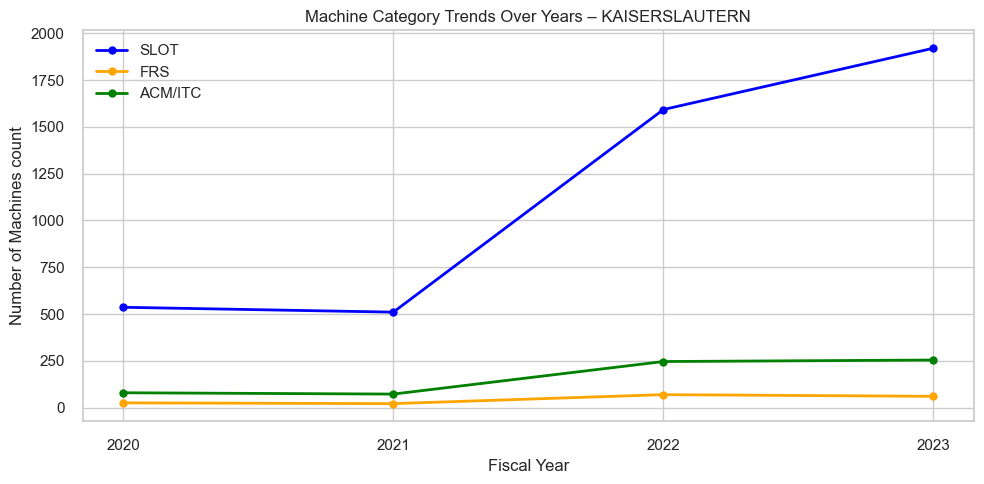

In [247]:
plot_all_categories_for_base(ar4, "KAISERSLAUTERN")

In [248]:
# Region and Base Analysis
print(ar4["REGION"].value_counts())
print(ar4[["REGION", "Base_clean"]].head())

base_region_counts = (
    ar4.dropna(subset=["REGION", "Base_clean"])
      .groupby(["REGION", "Base_clean"])
      .size()
      .reset_index(name="machine_count")
)

# top 5 bases by machine count
top_bases_per_region = (
    base_region_counts
    .sort_values(["REGION", "machine_count"], ascending=[True, False])
    .groupby("REGION")
    .head(5)
)

top_bases_per_region

REGION
Europe    31951
Japan     29690
Korea     17283
Name: count, dtype: int64
   REGION      Base_clean
0  Europe  KAISERSLAUTERN
1  Europe  KAISERSLAUTERN
2  Europe  KAISERSLAUTERN
3  Europe  KAISERSLAUTERN
4  Europe  KAISERSLAUTERN


,REGION,Base_clean,machine_count
3,Europe,KAISERSLAUTERN,6959
10,Europe,VILSECK,4619
11,Europe,WIESBADEN,3658
8,Europe,STUTTGART,3543
9,Europe,VICENZA,3086
14,Japan,OKINAWA,13641
17,Japan,ZAMA,5833
16,Japan,YOKOSUKA,4802
15,Japan,SASEBO,2887
13,Japan,IWAKUNI,2527


In [249]:
# Mapping regions to their top bases
region_to_bases = (
    top_bases_per_region
    .groupby("REGION")["Base_clean"]
    .apply(list)
    .to_dict()
)

region_to_bases


{'Europe': ['KAISERSLAUTERN', 'VILSECK', 'WIESBADEN', 'STUTTGART', 'VICENZA'],
 'Japan': ['OKINAWA', 'ZAMA', 'YOKOSUKA', 'SASEBO', 'IWAKUNI'],
 'Korea': ['PYONGTAEK', 'DAEGU', 'SEOUL', 'UIJEONGBU', 'SINGAPORE']}


=== Region: Europe ===
Plotting for base: KAISERSLAUTERN


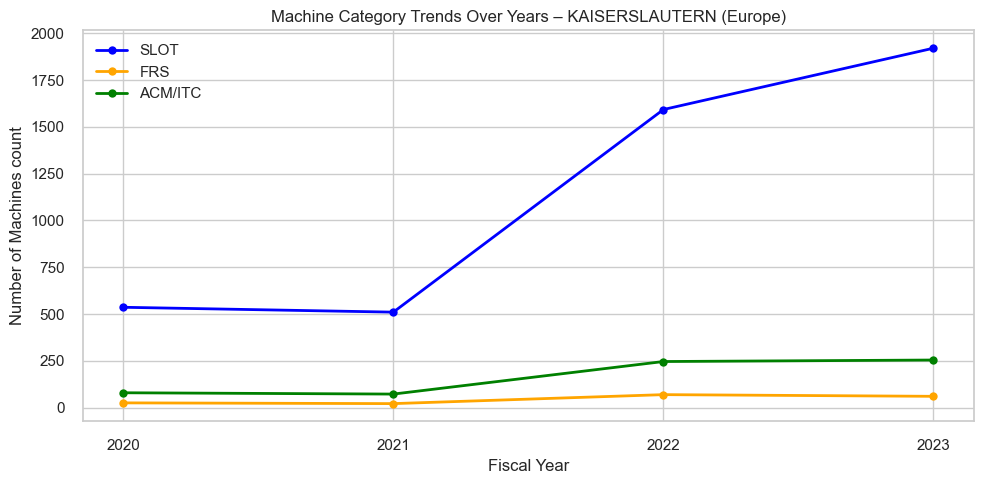

Plotting for base: VILSECK


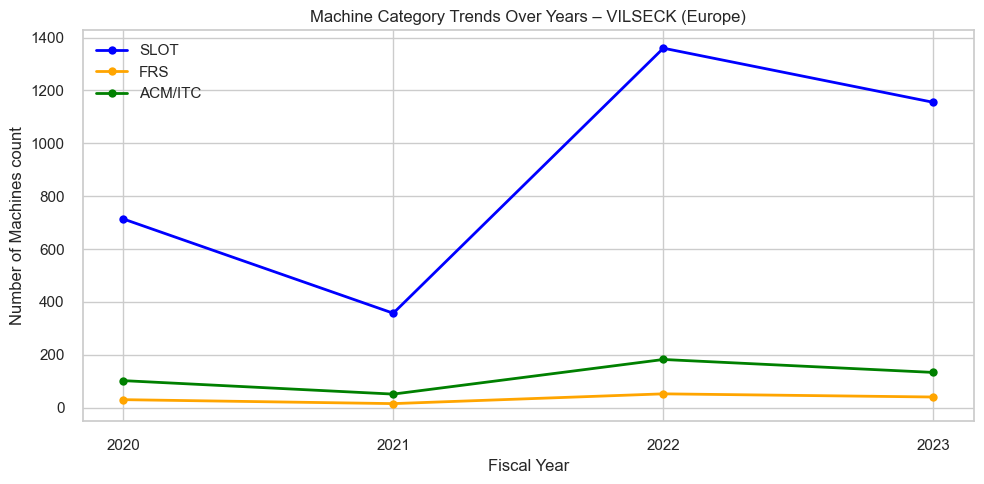

Plotting for base: WIESBADEN


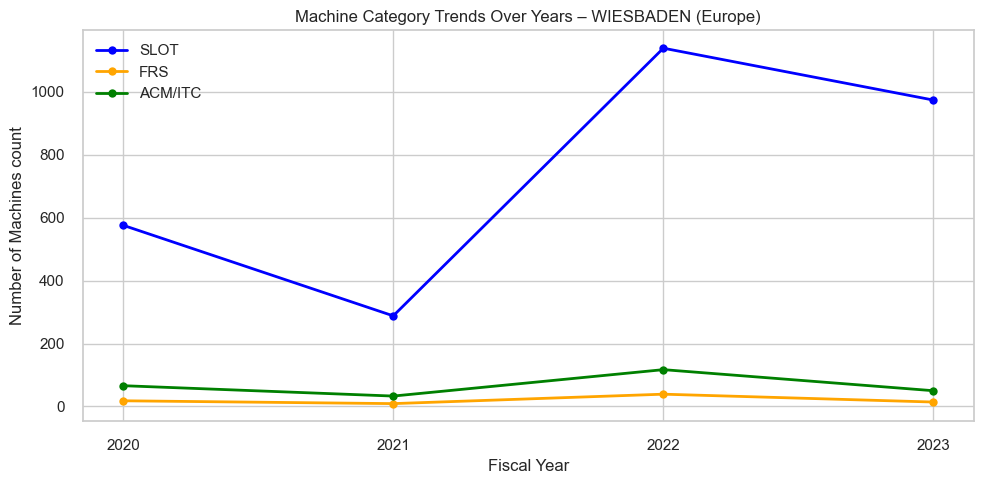

Plotting for base: STUTTGART


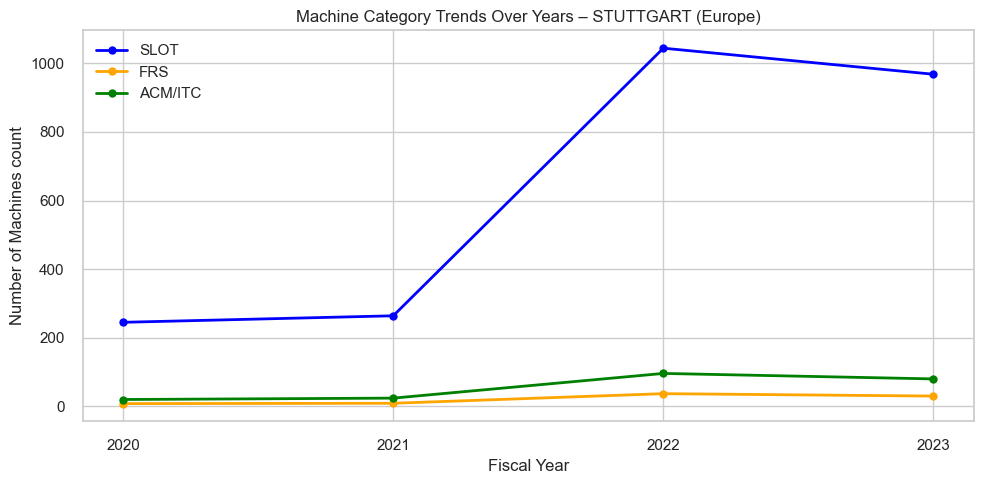

Plotting for base: VICENZA


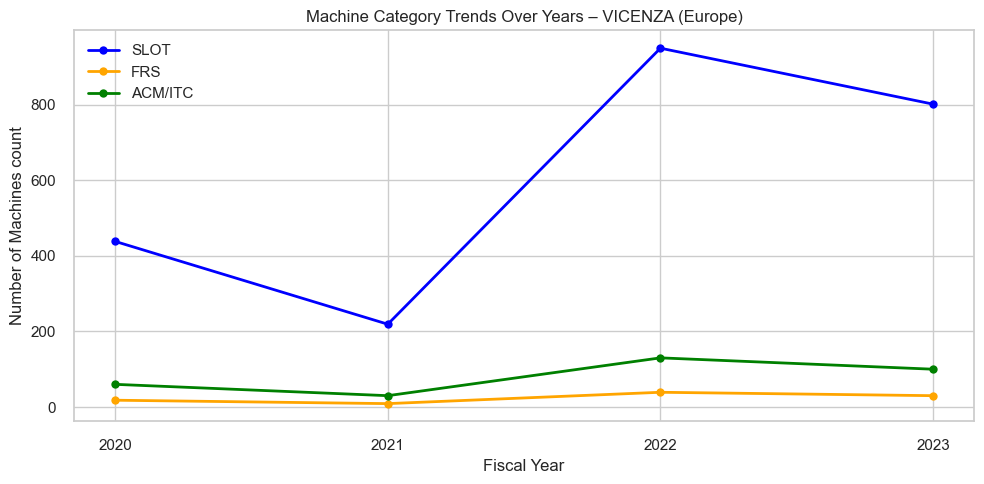


=== Region: Japan ===
Plotting for base: OKINAWA


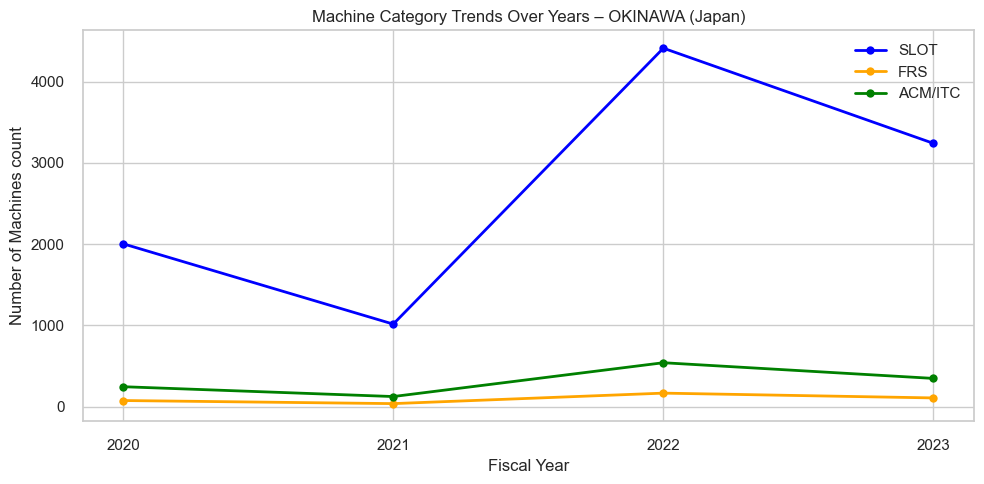

Plotting for base: ZAMA


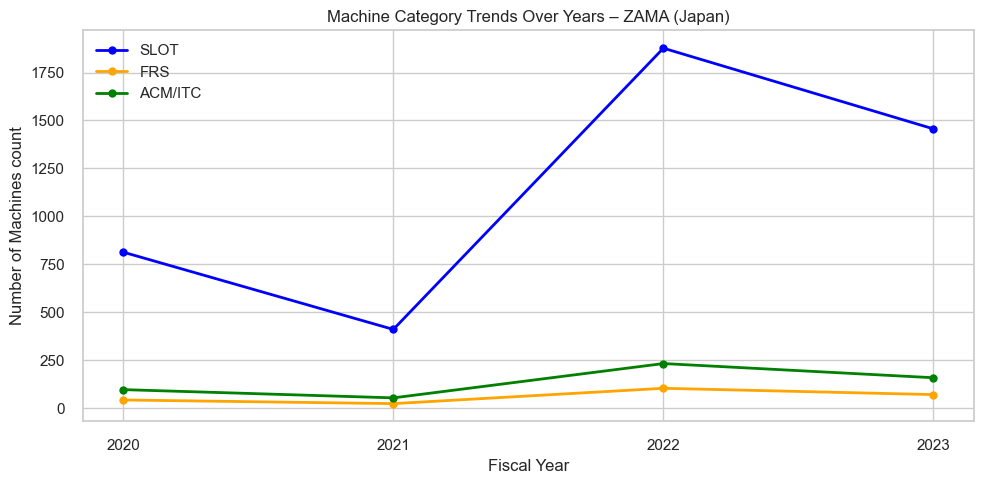

Plotting for base: YOKOSUKA


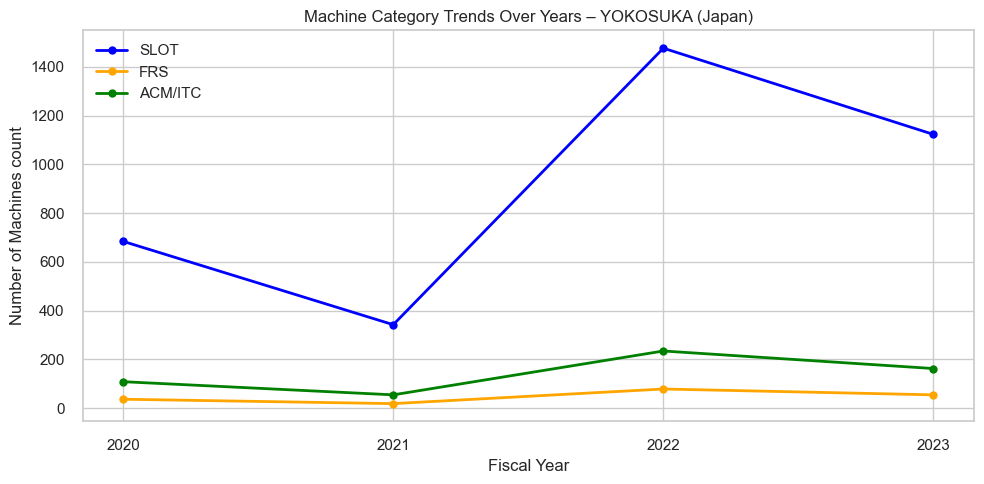

Plotting for base: SASEBO


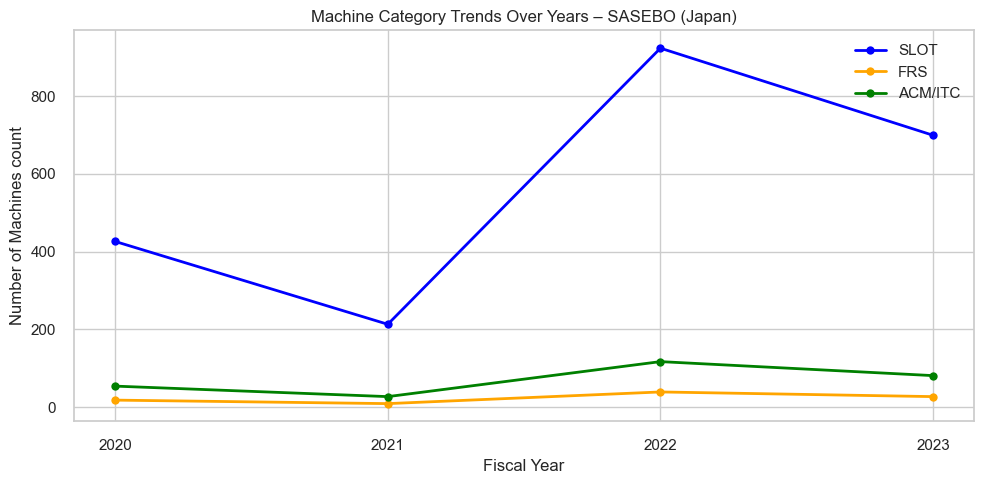

Plotting for base: IWAKUNI


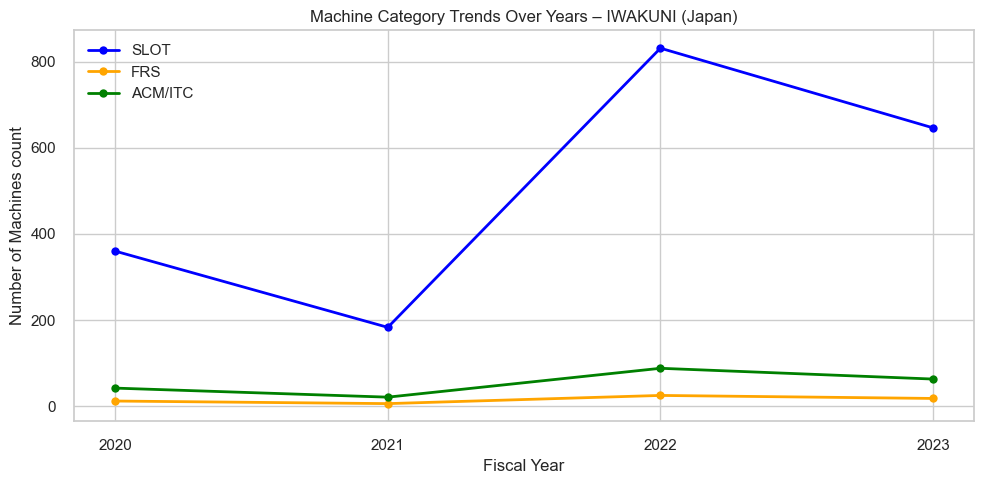


=== Region: Korea ===
Plotting for base: PYONGTAEK


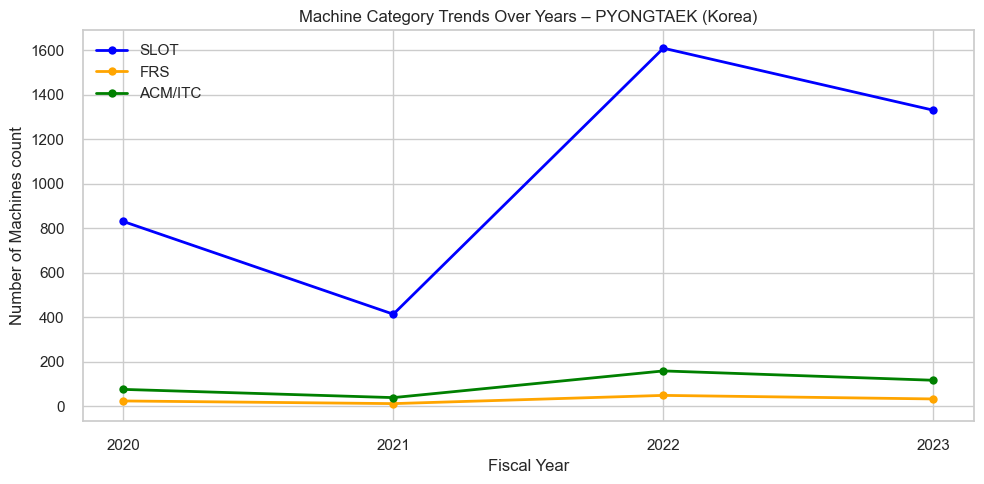

Plotting for base: DAEGU


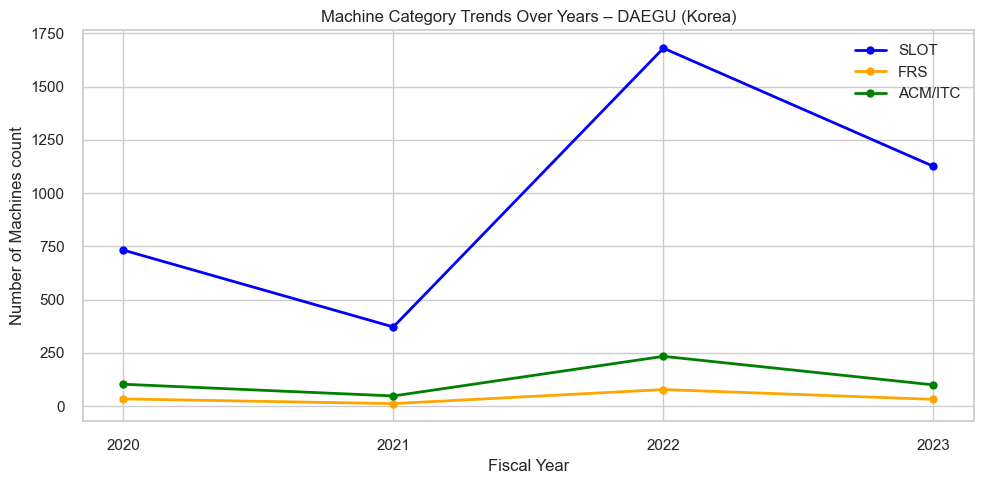

Plotting for base: SEOUL


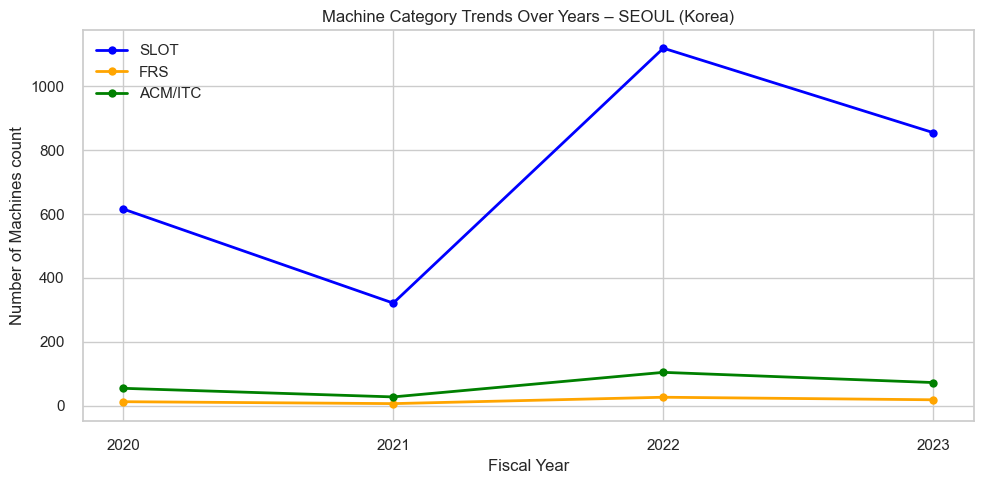

Plotting for base: UIJEONGBU


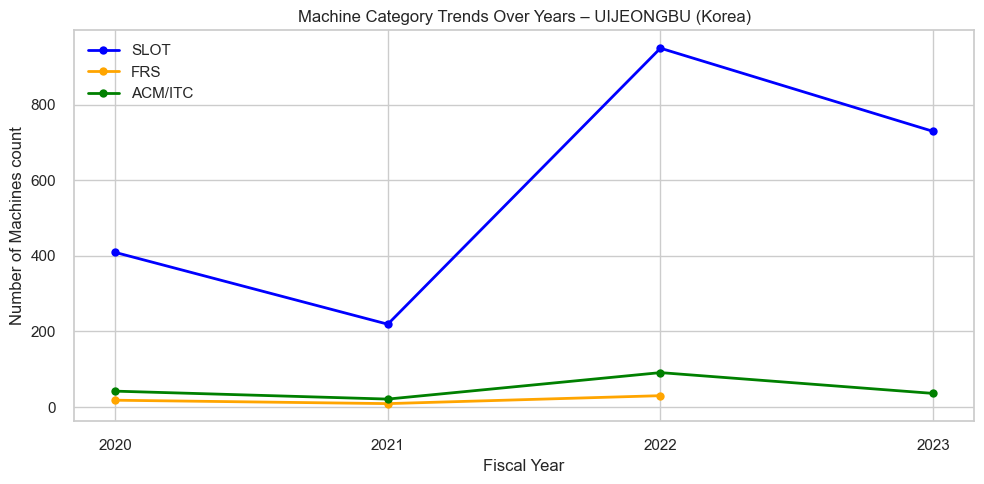

Plotting for base: SINGAPORE


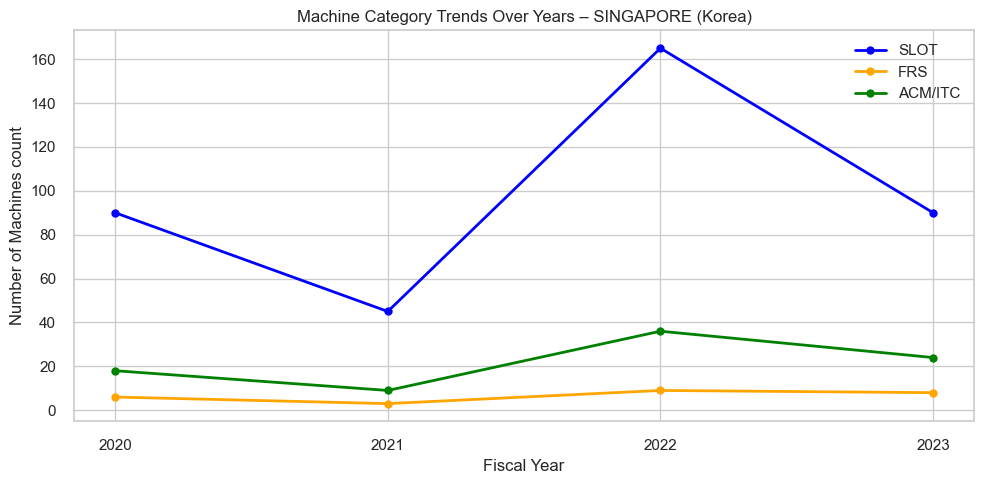

In [250]:
# Plotting for each region and its top bases
for region, base_list in region_to_bases.items():
    print(f"\n=== Region: {region} ===")
    for base in base_list:
        print(f"Plotting for base: {base}")
        plot_all_categories_for_base(ar4, base, region_name=region)

In [251]:
# Slot Machine Count Per Base Per Year

slot_df = ar4[ar4["Cat_clean"] == "SLOT"].copy()

slot_base_year_table = (
    slot_df
    .dropna(subset=["Base_clean", "FY_int"])
    .groupby(["Base_clean", "FY_int"])
    .size()
    .reset_index(name="slot_count")
    .pivot(index="Base_clean", columns="FY_int", values="slot_count")
    .fillna(0)
    .astype(int)
)

slot_base_year_table


FY_int,2020,2021,2022,2023
Base_clean,,,,
ANSBACH,216,108,468,396
DAEGU,733,372,1681,1126
GARMISCH,138,69,283,167
IWAKUNI,360,183,831,646
KAISERSLAUTERN,536,510,1593,1921
NAPLES,282,141,611,517
OKINAWA,2005,1017,4411,3240
PYONGTAEK,831,414,1610,1331
ROTA,366,171,741,682


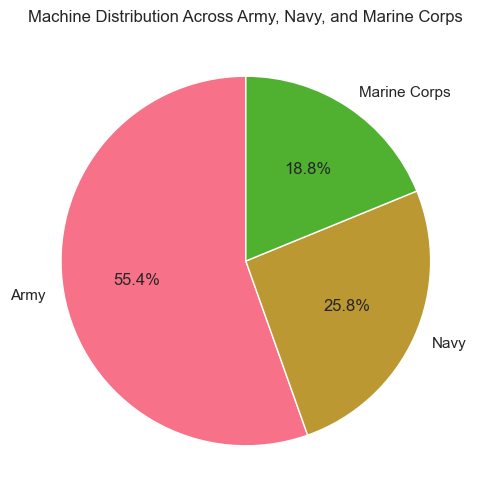

In [252]:
# Machine Distribution by branch
ar4["SVC_clean"] = (
    ar4["SVC"]
    .astype(str)
    .str.extract(r"(Army|Navy|Marine Corps)", expand=False)
)

branch_counts = ar4["SVC_clean"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    branch_counts,
    labels=branch_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title("Machine Distribution Across Army, Navy, and Marine Corps")
plt.show()

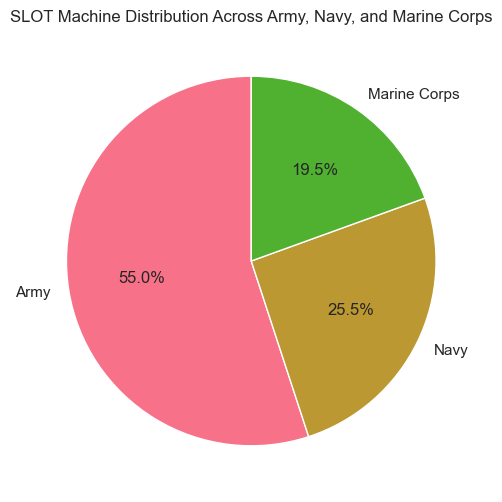

In [253]:
# Slot Machine Distribution by branch
slot_df = ar4[ar4["Cat_clean"] == "SLOT"]

slot_branch_counts = slot_df["SVC_clean"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    slot_branch_counts,
    labels=slot_branch_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
plt.title("SLOT Machine Distribution Across Army, Navy, and Marine Corps")
plt.show()


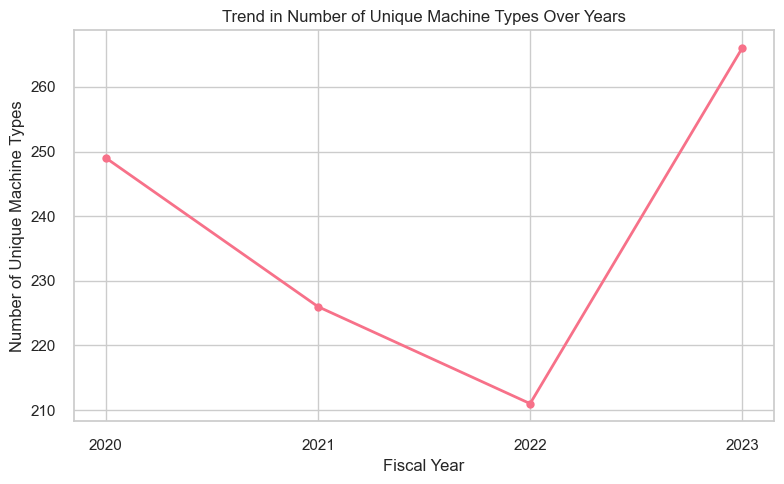

In [254]:
# Count how many distinct machine Types exist each Fiscal Year
types_per_year = (
    ar4.dropna(subset=["FY_int", "Type_str"])
      .groupby("FY_int")["Type_str"]
      .nunique()
      .reset_index(name="unique_types")
      .sort_values("FY_int")
)

# Plot
plt.figure(figsize=(8,5))
plt.plot(types_per_year["FY_int"], types_per_year["unique_types"], marker="o", linewidth=2)
plt.title("Trend in Number of Unique Machine Types Over Years")
plt.xlabel("Fiscal Year")
plt.ylabel("Number of Unique Machine Types")
plt.xticks(types_per_year["FY_int"])
plt.grid(True)
plt.tight_layout()
plt.show()


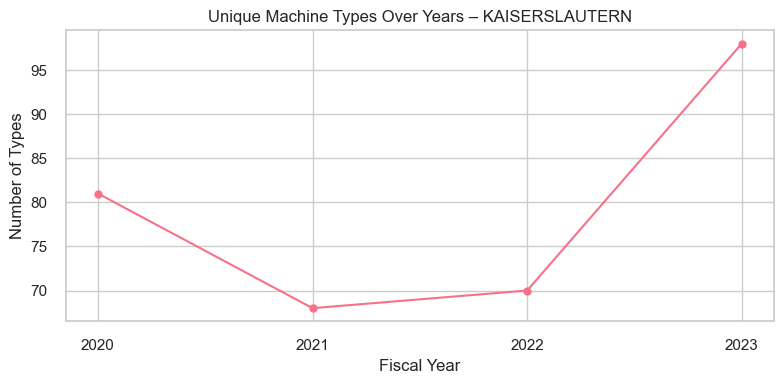

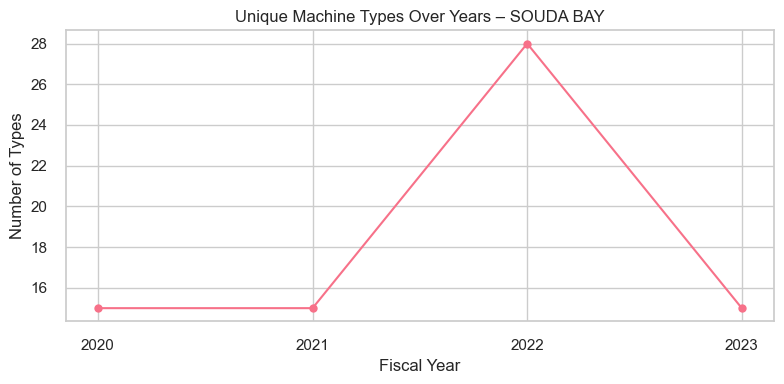

In [255]:
# Unique Machine Types Per Base Over Time
def plot_unique_types_per_base(df, base_name):
    base_df = ar4[df["Base_clean"] == base_name]

    types_year = (
        base_df.dropna(subset=["FY_int", "Type_str"])
               .groupby("FY_int")["Type_str"]
               .nunique()
               .reset_index(name="unique_types")
               .sort_values("FY_int")
    )

    if types_year.empty:
        print(f"No data for base: {base_name}")
        return

    plt.figure(figsize=(8,4))
    plt.plot(types_year["FY_int"], types_year["unique_types"], marker="o")
    plt.title(f"Unique Machine Types Over Years – {base_name}")
    plt.xlabel("Fiscal Year")
    plt.ylabel("Number of Types")
    plt.xticks(types_year["FY_int"])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_unique_types_per_base(ar4, "KAISERSLAUTERN")
plot_unique_types_per_base(ar4, "SOUDA BAY")


### Format 2

In [256]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Path to the CSV (update this to your actual path if needed)
csv_path = FMT2_CSV_PATH

df = pd.read_csv(csv_path)
df.head()

,Country,FO#,LOC,SVC,NOV,AIN,IGT,WMS,BAL,KON,...,DIE,COU,ACM,ITC,Total,Month,Year,Region,latitude,longitude
0,IRISH PUB,2,194,NaN,14,4,10,-,10,4,...,2,-,NaN,3,48,1,2020,Europe,NaN,NaN
1,LCCC,2,195,NaN,10,3,5,3,7,2,...,2,-,NaN,2,35,1,2020,Europe,NaN,NaN
2,KAZABRA,2,196,NaN,6,-,4,-,-,2,...,1,-,NaN,1,15,1,2020,Europe,NaN,NaN
3,STRIKERS,2,218,NaN,11,4,7,2,6,3,...,2,-,NaN,2,38,1,2020,Europe,NaN,NaN
4,THE GOLD MINE,2,1038,NaN,8,4,4,3,3,-,...,2,-,NaN,2,27,1,2020,Europe,NaN,NaN


In [257]:
# Define provider and related numeric columns
provider_cols = ["NOV", "AIN", "IGT", "WMS", "BAL", "KON", "ITE"]
numeric_cols = provider_cols + ["Tot/EGMs", "FRS", "DIE", "COU", "ACM", "ITC", "Total"]

# Replace '-' with 0 and convert to numeric
df[numeric_cols] = (
    df[numeric_cols]
    .replace("-", 0)
    .apply(pd.to_numeric, errors="coerce")
)

print("Data types for key columns:")
print(df[numeric_cols].dtypes)

print("\nProvider column totals (sanity check):")
print(df[provider_cols].sum())

Data types for key columns:
NOV         float64
AIN         float64
IGT         float64
WMS         float64
BAL         float64
KON         float64
ITE         float64
Tot/EGMs    float64
FRS         float64
DIE         float64
COU         float64
ACM         float64
ITC         float64
Total       float64
dtype: object

Provider column totals (sanity check):
NOV    50678.0
AIN    20889.0
IGT    28631.0
WMS     9540.0
BAL    36335.0
KON     9929.0
ITE     3190.0
dtype: float64


Total machines by provider (FY20–FY24):


,Total Machines
NOV,50678.0
BAL,36335.0
IGT,28631.0
AIN,20889.0
KON,9929.0
WMS,9540.0
ITE,3190.0


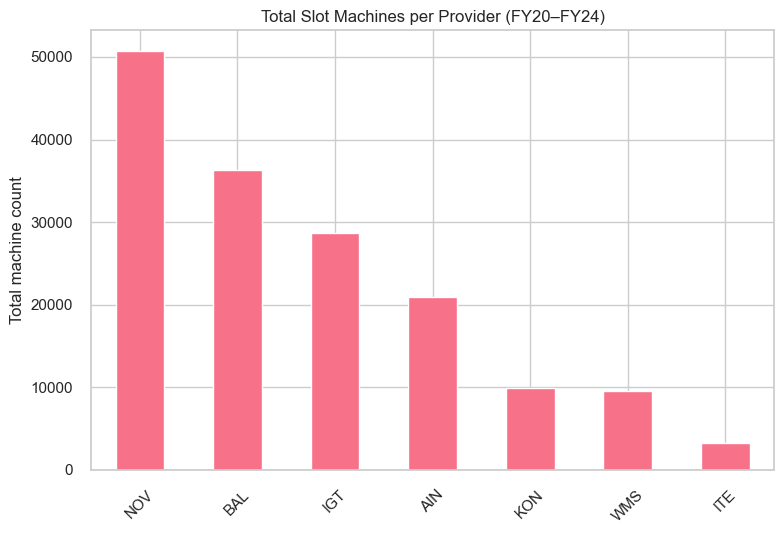

In [258]:
# 1. Total machines per provider (overall)

total_by_provider = df[provider_cols].sum().sort_values(ascending=False)
print("Total machines by provider (FY20–FY24):")
display(total_by_provider.to_frame(name="Total Machines"))

plt.figure()
total_by_provider.plot(kind="bar")
plt.ylabel("Total machine count")
plt.title("Total Slot Machines per Provider (FY20–FY24)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Provider totals by year:


,NOV,AIN,IGT,WMS,BAL,KON,ITE
Year,,,,,,,
2020,9672.0,2414.0,4436.0,1838.0,5512.0,1624.0,168.0
2021,3861.0,1328.0,1891.0,707.0,2821.0,656.0,45.0
2021.0,6752.0,4022.0,5516.0,2136.0,7972.0,1924.0,210.0
2022,15360.0,4946.0,6633.0,2523.0,9793.0,1771.0,1587.0
2023,11346.0,5752.0,6169.0,2152.0,6901.0,3082.0,1164.0
2024,3687.0,2427.0,3986.0,184.0,3336.0,872.0,16.0
Year,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Provider market share by year:


,NOV,AIN,IGT,WMS,BAL,KON,ITE
Year,,,,,,,
2020,0.376870,0.094062,0.172849,0.071618,0.214776,0.063279,0.006546
2021,0.341409,0.117429,0.167212,0.062517,0.249447,0.058007,0.003979
2021.0,0.236647,0.140965,0.193327,0.074863,0.279406,0.067433,0.007360
2022,0.360453,0.116068,0.155657,0.059207,0.229812,0.041560,0.037242
2023,0.310288,0.157305,0.168709,0.058852,0.188727,0.084286,0.031833
2024,0.254136,0.167287,0.274745,0.012683,0.229942,0.060105,0.001103
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN


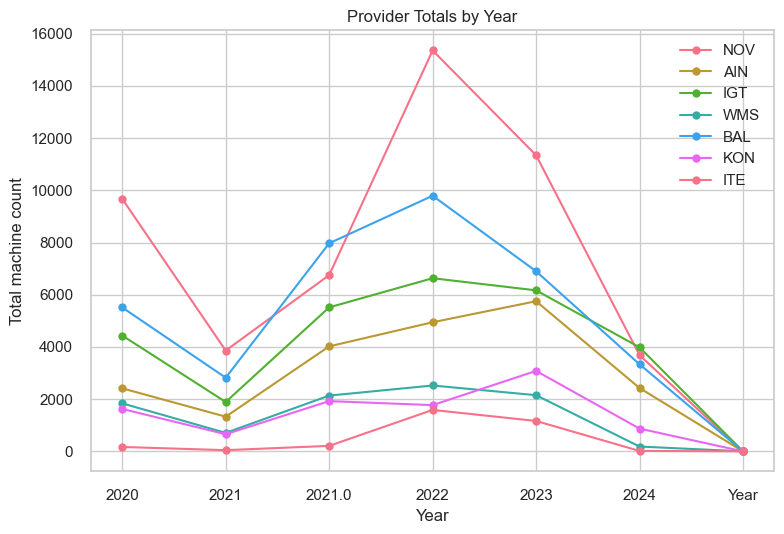

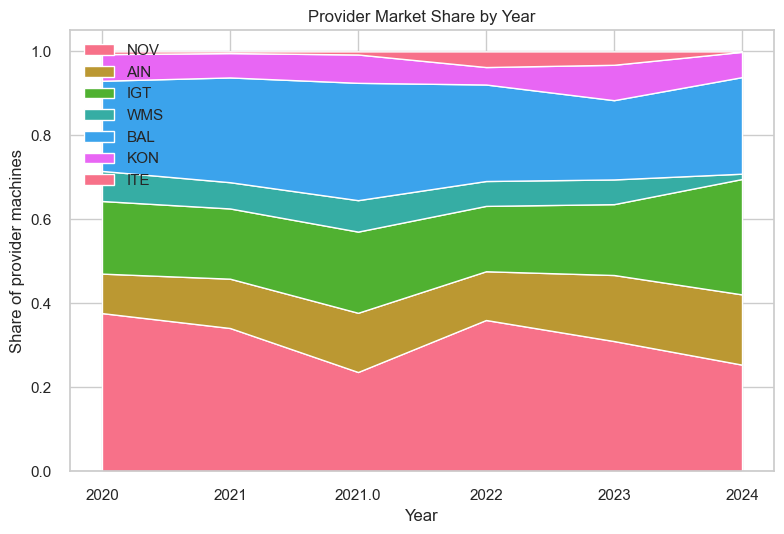

In [259]:
# 2. Provider market share by year

provider_by_year = df.groupby("Year")[provider_cols].sum()
print("Provider totals by year:")
display(provider_by_year)

provider_share_by_year = provider_by_year.div(provider_by_year.sum(axis=1), axis=0)
print("\nProvider market share by year:")
display(provider_share_by_year)

plt.figure()
for col in provider_cols:
    plt.plot(provider_by_year.index, provider_by_year[col], marker="o", label=col)

plt.xlabel("Year")
plt.ylabel("Total machine count")
plt.title("Provider Totals by Year")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.stackplot(
    provider_share_by_year.index,
    [provider_share_by_year[col] for col in provider_cols],
    labels=provider_cols
)
plt.xlabel("Year")
plt.ylabel("Share of provider machines")
plt.title("Provider Market Share by Year")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

Provider totals by region:


,NOV,AIN,IGT,WMS,BAL,KON,ITE
Region,,,,,,,
Europe,26256.0,7410.0,12993.0,4190.0,16491.0,4728.0,1864.0
Japan,17148.0,9538.0,11019.0,3794.0,12878.0,3847.0,980.0
Korea,7271.0,3934.0,4605.0,1542.0,6937.0,1348.0,345.0



Provider share by region:


,NOV,AIN,IGT,WMS,BAL,KON,ITE
Region,,,,,,,
Europe,0.355137,0.100227,0.175743,0.056674,0.223056,0.063951,0.025212
Japan,0.289643,0.161104,0.186119,0.064084,0.217519,0.064979,0.016553
Korea,0.279848,0.151413,0.177238,0.059349,0.266993,0.051882,0.013278


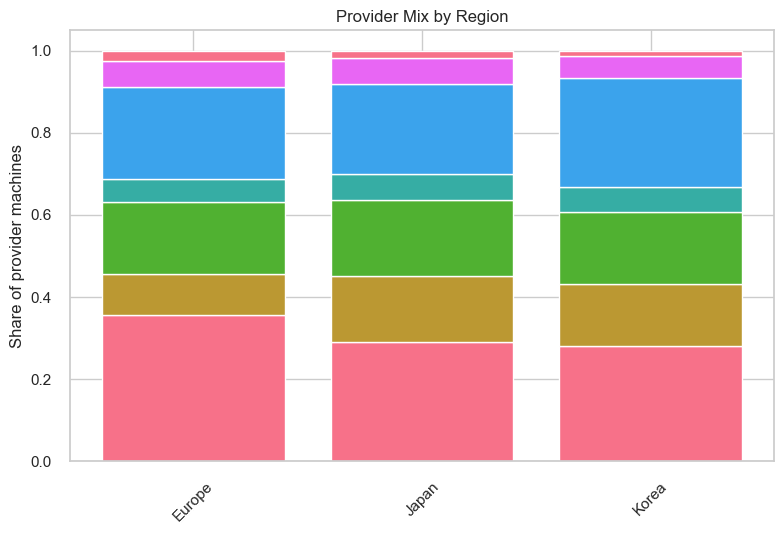

In [260]:
# 3. Provider distribution by region

provider_by_region = df.groupby("Region")[provider_cols].sum()
print("Provider totals by region:")
display(provider_by_region)

provider_share_by_region = provider_by_region.div(provider_by_region.sum(axis=1), axis=0)
print("\nProvider share by region:")
display(provider_share_by_region)

plt.figure()
bottom = None
for col in provider_cols:
    if bottom is None:
        bottom = provider_share_by_region[col]
        plt.bar(provider_share_by_region.index, provider_share_by_region[col])
    else:
        plt.bar(provider_share_by_region.index, provider_share_by_region[col], bottom=bottom)
        bottom = bottom + provider_share_by_region[col]

plt.ylabel("Share of provider machines")
plt.title("Provider Mix by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total EGMs by year:


,Total EGMs
Year,
2020,26908.0
2021,10513.0
2021.0,34970.0
2022,48891.0
2023,35151.0
2024,19302.0
Year,0.0


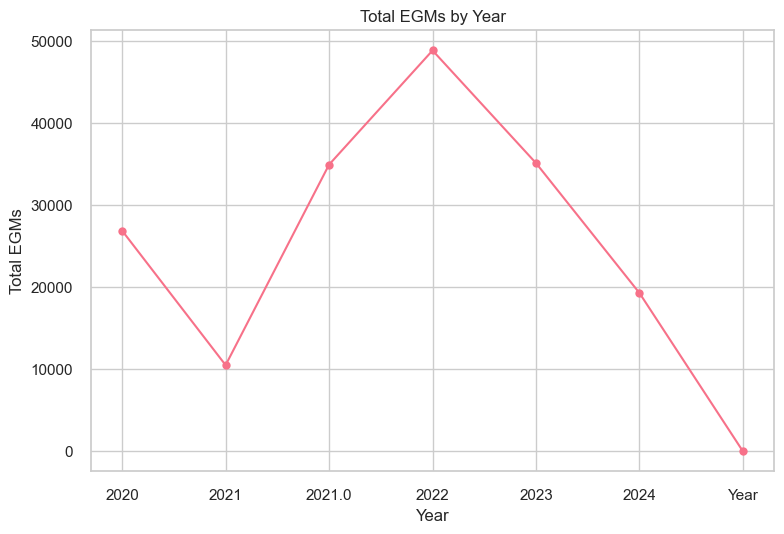

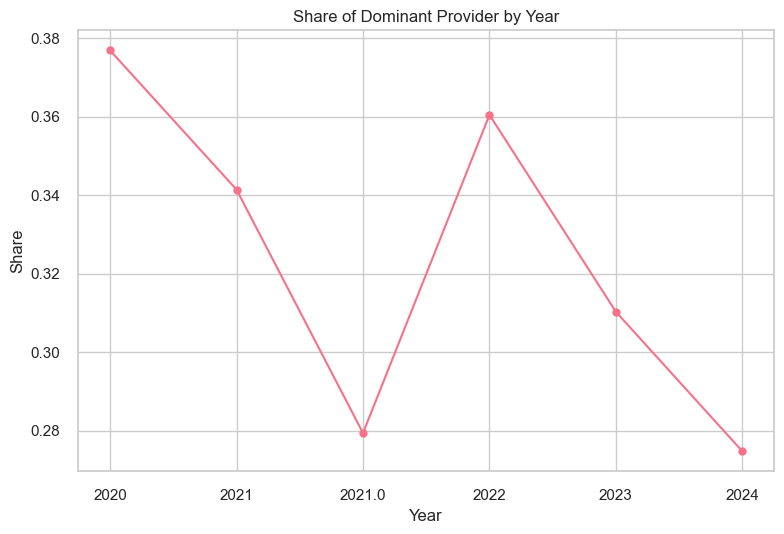

In [261]:
# 4. Trend analysis: Tot/EGMs and provider concentration over time

egms_by_year = df.groupby("Year")["Tot/EGMs"].sum()
print("Total EGMs by year:")
display(egms_by_year.to_frame(name="Total EGMs"))

plt.figure()
egms_by_year.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Total EGMs")
plt.title("Total EGMs by Year")
plt.tight_layout()
plt.show()

top_share_by_year = provider_share_by_year.max(axis=1)
plt.figure()
top_share_by_year.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Share")
plt.title("Share of Dominant Provider by Year")
plt.tight_layout()
plt.show()

Summary of number of providers per row:


,num_providers
count,5867.000000
mean,3.615306
std,2.022324
min,0.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,7.000000



Average number of providers per location by region:


,Average Providers
Region,
Europe,3.787555
Japan,3.725722
Korea,3.085366


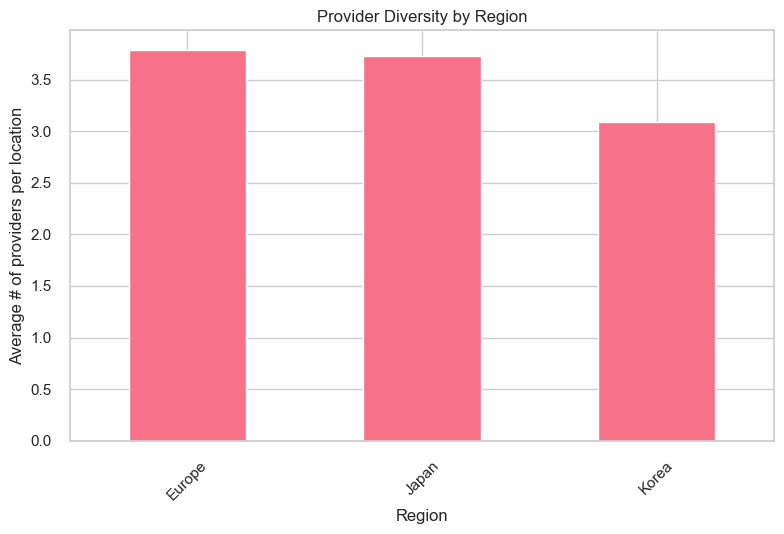

In [262]:
# 5. Location-level diversity: how many distinct providers per row?

def count_nonzero_providers(row):
    return (row[provider_cols] > 0).sum()

df["num_providers"] = df.apply(count_nonzero_providers, axis=1)

print("Summary of number of providers per row:")
display(df["num_providers"].describe().to_frame(name="num_providers"))

providers_per_region = df.groupby("Region")["num_providers"].mean()
print("\nAverage number of providers per location by region:")
display(providers_per_region.to_frame(name="Average Providers"))

plt.figure()
providers_per_region.plot(kind="bar")
plt.ylabel("Average # of providers per location")
plt.title("Provider Diversity by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Biggest provider in each region:


,Top Provider,Machines
Region,,
Europe,NOV,26256.0
Japan,NOV,17148.0
Korea,NOV,7271.0


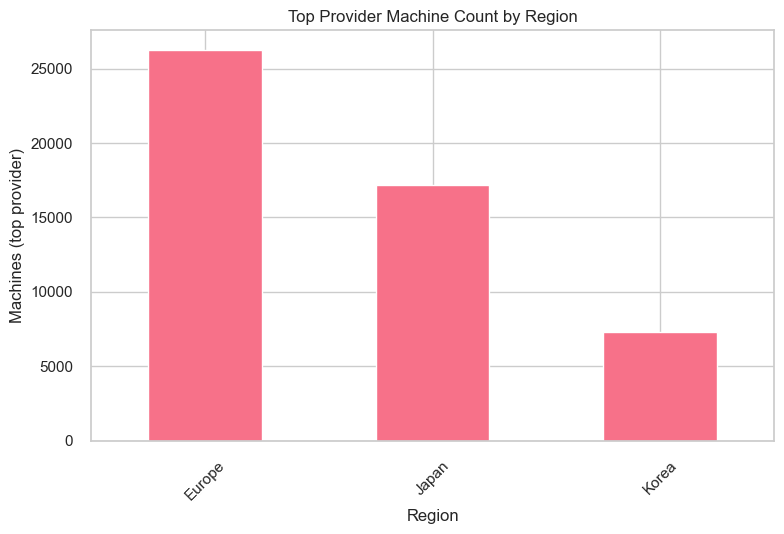

In [263]:
# 6. Biggest provider in each region

region_totals = df.groupby("Region")[provider_cols].sum()

biggest_provider_region = pd.DataFrame({
    "Top Provider": region_totals.idxmax(axis=1),
    "Machines": region_totals.max(axis=1)
}).sort_values("Machines", ascending=False)

print("Biggest provider in each region:")
display(biggest_provider_region)

plt.figure()
biggest_provider_region["Machines"].plot(kind="bar")
plt.ylabel("Machines (top provider)")
plt.title("Top Provider Machine Count by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 10 bases by total EGMs:


,Country,LOC,Region,Tot/EGMs
0,OKINAWA,0,Japan,358.0
1,OKINAWA,0,Japan,357.0
2,OKINAWA,0,Japan,357.0
3,THE ANCHOR,2618,Europe,341.0
4,OKINAWA,0,Japan,341.0
5,DRAGON HILL,770\r\n776 I,Korea,341.0
6,OKINAWA,0,Japan,341.0
7,OKINAWA,0,Japan,341.0
8,KAZABRA,196,Europe,341.0
9,HOHENFELS B/C,415,Europe,341.0


) missing from font(s) Arial.mp\ipykernel_1744\993236675.py:18: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) Arial.S701\ds-muckrock-liberation\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


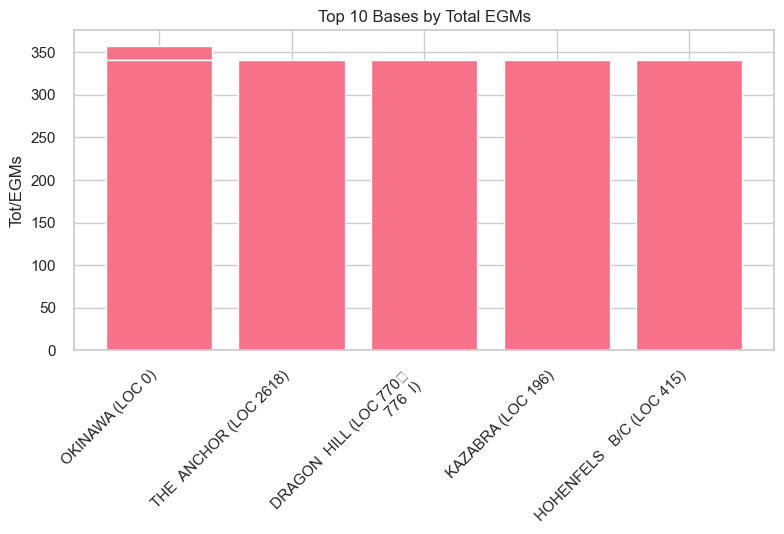

In [264]:
# 7. Bases with the highest total number of machines (Tot/EGMs)

top_bases = (
    df[["Country", "LOC", "Region", "Tot/EGMs"]]
    .sort_values("Tot/EGMs", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 bases by total EGMs:")
display(top_bases)

plt.figure()
plt.bar(top_bases["Country"].astype(str) + " (LOC " + top_bases["LOC"].astype(str) + ")", top_bases["Tot/EGMs"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Tot/EGMs")
plt.title("Top 10 Bases by Total EGMs")
plt.tight_layout()
plt.show()

In [265]:
# 8. Location where each provider has its maximum machine count

max_rows = []

for provider in provider_cols:
    max_count = df[provider].max()
    subset = df[df[provider] == max_count]
    for _, row in subset.iterrows():
        max_rows.append({
            "Provider": provider,
            "Max Machines": max_count,
            "Country": row["Country"],
            "LOC": row["LOC"],
            "Region": row["Region"]
        })

provider_max_locations = pd.DataFrame(max_rows).drop_duplicates()
provider_max_locations = provider_max_locations.sort_values(["Provider", "Max Machines"], ascending=[True, False])

print("Location(s) where each provider has its highest machine count:")
display(provider_max_locations)

Location(s) where each provider has its highest machine count:


,Provider,Max Machines,Country,LOC,Region
3,AIN,224.0,SEMBACH C/C,3072,Europe
6,BAL,451.0,SEMBACH C/C,3072,Europe
4,IGT,296.0,SEMBACH C/C,3072,Europe
8,ITE,85.0,NaN,0,Europe
9,ITE,85.0,CAPO OLDE TOWN,2588,Europe
10,ITE,85.0,ROTA FLEET CTR,2605,Europe
11,ITE,85.0,KELLY C/C,280,Europe
12,ITE,85.0,LANGENBRUCK,1858,Europe
13,ITE,85.0,ACE'S GAME RM,3108,Europe
14,ITE,85.0,TAKEMIYA CLUB,3149,Japan


Provider by Region matrix:


,NOV,AIN,IGT,WMS,BAL,KON,ITE
Region,,,,,,,
Europe,26256.0,7410.0,12993.0,4190.0,16491.0,4728.0,1864.0
Japan,17148.0,9538.0,11019.0,3794.0,12878.0,3847.0,980.0
Korea,7271.0,3934.0,4605.0,1542.0,6937.0,1348.0,345.0


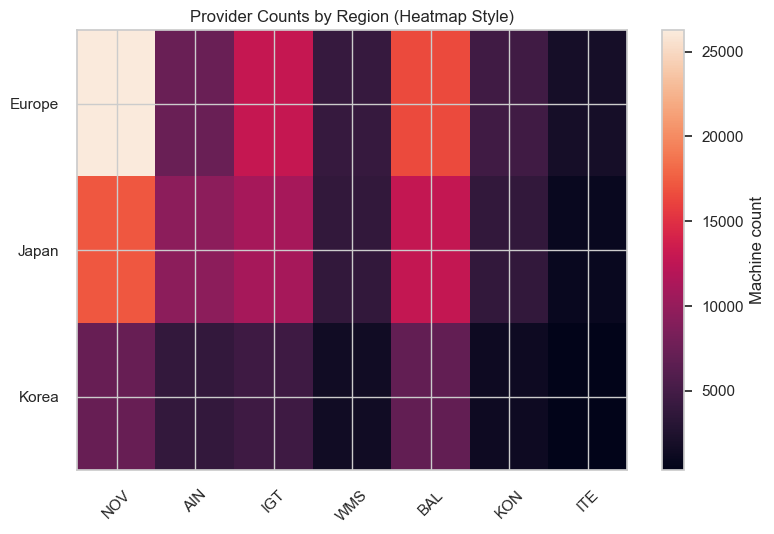

In [266]:
# 9. Provider vs Region matrix (heatmap-style plot)

provider_by_region = df.groupby("Region")[provider_cols].sum()

print("Provider by Region matrix:")
display(provider_by_region)

plt.figure()
plt.imshow(provider_by_region.values, aspect="auto")
plt.colorbar(label="Machine count")
plt.xticks(range(len(provider_cols)), provider_cols, rotation=45)
plt.yticks(range(len(provider_by_region.index)), provider_by_region.index)
plt.title("Provider Counts by Region (Heatmap Style)")
plt.tight_layout()
plt.show()

Top 10 bases with coordinates:


,Country,LOC,Region,Tot/EGMs,latitude,longitude
410,OKINAWA,0,Japan,358.0,26.212401,127.680930
215,OKINAWA,0,Japan,357.0,26.212401,127.680930
92,OKINAWA,0,Japan,357.0,26.212401,127.680930
3650,OKINAWA,0,Japan,341.0,26.212401,127.680930
1993,OKINAWA,0,Japan,341.0,26.212401,127.680930
3135,NAPLES B/C,2591,Europe,341.0,40.851775,14.268124
3775,OKINAWA,0,Japan,341.0,26.212401,127.680930
3900,OKINAWA,0,Japan,341.0,26.212401,127.680930
3525,OKINAWA,NaN,Japan,341.0,26.212401,127.680930
4025,OKINAWA,0,Japan,341.0,26.212401,127.680930


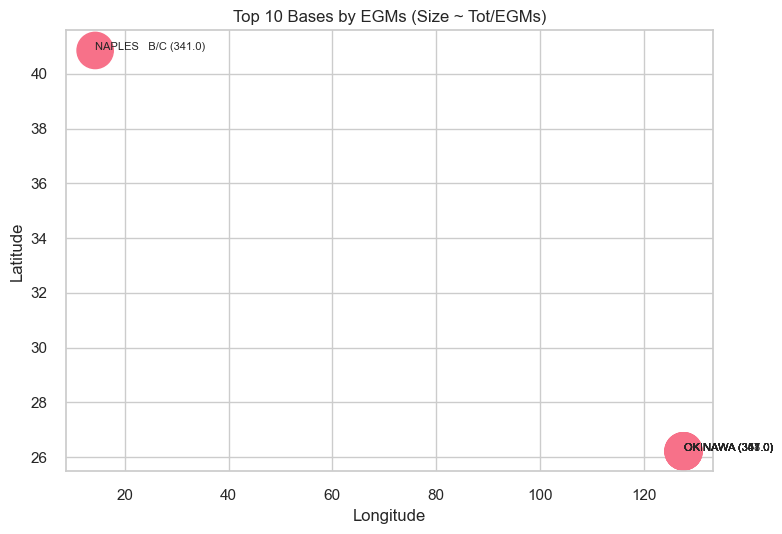

In [267]:
# 10. Simple map-style scatter for top 10 bases (requires latitude/longitude)

top_bases_geo = (
    df.dropna(subset=["latitude", "longitude"])
      .sort_values("Tot/EGMs", ascending=False)
      .head(10)
)

print("Top 10 bases with coordinates:")
display(top_bases_geo[["Country", "LOC", "Region", "Tot/EGMs", "latitude", "longitude"]])

plt.figure()
plt.scatter(top_bases_geo["longitude"], top_bases_geo["latitude"], s=top_bases_geo["Tot/EGMs"] * 2)
for _, row in top_bases_geo.iterrows():
    label = f"{row['Country']} ({row['Tot/EGMs']})"
    plt.text(row["longitude"], row["latitude"], label, fontsize=8)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Top 10 Bases by EGMs (Size ~ Tot/EGMs)")
plt.tight_layout()
plt.show()